Objective in this part:
定义值得解释的neuron representation, 不同菌株相关刺激引起了哪些稳定的感觉神经响应差异？


calcium imaging尤其是目前的nucleus calcium imaging相当于cell-wide integrated activity state，第一重要的是谁响应、以什么方向响应，
重要性的排序大致是：

$$ \boxed{ \text{response identity/type} > \text{response amplitude} > \text{ON/OFF structure} > \text{sustained vs transient/adaptation} > \text{rise dynamics} > \text{latency} > \text{precise peak time / decay constant} } $$

用的是 nuclear GCaMP6s/7s，需要进一步降低最后三项的权重。并且后续分析时：更推荐“不把 trace 强行压成很多人工参数”

我们讨论目前的chemosensory population coding时：
$\boxed{
\text{population coding 首先看“谁响应 + 响应多强 + ON/OFF”；}
}$

$
\boxed{
\text{temporal coding 重点看“响应形状是否真的不同”，而不是微小的时间参数差异。}
}$

## 01 Inspect Repeated Bacteria across dates

objective: 评估跨日期（批次）bacteria响应特征的稳定性

In [1]:
from pathlib import Path
from itertools import permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

SEED = 20260915

# 两项需要分别重跑的敏感性分析
POOL_BILATERAL = True
INCLUDE_T15_IN_STIMULUS = False

REPEATED_SAMPLES = ["A011", "A013", "A014", "A024", "A025", "A044"]

DROP_NEURONS = {
    "AFDL", "AFDR",
    "BAGL", "BAGR",
    "CEPR", "URXR",
}

BILATERAL_CLASSES = {
    "ASK": ["ASKL", "ASKR"],
    "ADL": ["ADLL", "ADLR"],
    "ASI": ["ASIL", "ASIR"],
    "AWA": ["AWAL", "AWAR"],
    "AWB": ["AWBL", "AWBR"],
    "ASG": ["ASGL", "ASGR"],
    "ADF": ["ADFL", "ADFR"],
    "ASH": ["ASHL", "ASHR"],
    "ASJ": ["ASJL", "ASJR"],
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "DejaVu Sans"
]

start = Path.cwd().resolve()
ROOT = next(
    (
        path for path in [start, *start.parents]
        if (path / "data" / "106bac.parquet").exists()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError("Cannot find data/106bac.parquet")

columns = [
    "date",
    "worm_key",
    "segment_index",
    "stim_name",
    "neuron",
    "time_point",
    "delta_F_over_F0",
]

df = pd.read_parquet(
    ROOT / "data" / "106bac.parquet",
    columns=columns,
)

df["sample_id"] = df["stim_name"].str.extract(
    r"^(A\d{3})",
    expand=False,
)
df["date"] = df["date"].astype(str)

df = df.loc[
    df["sample_id"].isin(REPEATED_SAMPLES)
    & ~df["neuron"].isin(DROP_NEURONS)
].copy()

neuron_to_class = {
    neuron: neuron_class
    for neuron_class, members in BILATERAL_CLASSES.items()
    for neuron in members
}

if POOL_BILATERAL:
    df["neuron_class"] = (
        df["neuron"].map(neuron_to_class).fillna(df["neuron"])
    )
else:
    df["neuron_class"] = df["neuron"]

print(f"Rows: {len(df):,}")
print(f"Samples: {df['sample_id'].nunique()}")
print(f"Dates: {df['date'].nunique()}")
print(f"Neuron channels: {df['neuron_class'].nunique()}")

Rows: 246,690
Samples: 6
Dates: 5
Neuron channels: 13


### Question
构建individual response feature

1. 在同一个 trial、同一个时间点，先对左右同类神经元取平均（启用 POOL_BILATERAL 时）。
2. 同一只动物对同一菌株的重复 trial，在各时间点取平均，得到这只动物的一条 trace。
3. 同一日期内，再对各只动物的 trace 逐时间点取平均，得到该日期的 trace。

In [2]:
# 先在每个trial、每个timepoint内合并L/R。
# 若两侧都存在，取两侧均值；若只有一侧，则使用已有的一侧。
trial_trace = (
    df.groupby(
        [
            "date",
            "worm_key",
            "sample_id",
            "segment_index",
            "neuron_class",
            "time_point",
        ],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
)

# 再平均同一individual对同一菌株的重复trial。
# 这样每个individual具有相同权重，不受trial数量影响。
individual_trace = (
    trial_trace.groupby(
        [
            "date",
            "worm_key",
            "sample_id",
            "neuron_class",
            "time_point",
        ],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
)

# 将响应期5–44秒划分为8个互不重叠的5秒窗口。
# 使用纯时间标签，避免预先把撤除后钙信号解释为特定神经过程。
TIME_BINS = {
    f"t{start:02d}_{start + 4:02d}": range(start, start + 5)
    for start in range(5, 45, 5)
}

time_bin_order = list(TIME_BINS)

time_bin_by_point = {
    time_point: time_bin
    for time_bin, time_points in TIME_BINS.items()
    for time_point in time_points
}

if set(time_bin_by_point) != set(range(5, 45)):
    raise ValueError(
        "The 5-second bins do not cover timepoints 5–44 exactly"
    )

binned_data = individual_trace.loc[
    individual_trace["time_point"].isin(time_bin_by_point)
].copy()

binned_data["time_bin"] = (
    binned_data["time_point"].map(time_bin_by_point)
)

# 每个值是一个individual、一个菌株、一个neuron class
# 在一个5秒窗口内的平均ΔF/F0。
individual_binned = (
    binned_data.groupby(
        [
            "sample_id",
            "date",
            "worm_key",
            "neuron_class",
            "time_bin",
        ],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
    .rename(columns={"delta_F_over_F0": "response"})
)

# 验证每个已有的individual-neuron trace都产生了8个时间窗口。
bin_count = (
    individual_binned.groupby(
        [
            "sample_id",
            "date",
            "worm_key",
            "neuron_class",
        ],
        observed=True,
    )["time_bin"]
    .nunique()
)

if not bin_count.eq(8).all():
    raise ValueError(
        "At least one individual-neuron trace is missing a 5-second bin"
    )

# 转换为individual级特征矩阵。
# 行：sample × date × individual
# 列：neuron class × 5-second time bin
feature = individual_binned.pivot(
    index=["sample_id", "date", "worm_key"],
    columns=["neuron_class", "time_bin"],
    values="response",
)

if POOL_BILATERAL:
    class_order = [
        *BILATERAL_CLASSES,
        "ASEL",
        "ASER",
        "AWCON",
        "AWCOFF",
    ]
else:
    class_order = sorted(df["neuron_class"].unique())

class_order = [
    neuron_class
    for neuron_class in class_order
    if neuron_class in set(df["neuron_class"])
]

expected_columns = pd.MultiIndex.from_product(
    [class_order, time_bin_order],
    names=["neuron_class", "time_bin"],
)

feature = feature.reindex(columns=expected_columns)

# 每个sample-date-neuron class实际有多少individual提供数据。
# 这是覆盖率，不是响应强度。
class_coverage = (
    individual_binned.groupby(
        ["sample_id", "date", "neuron_class"],
        observed=True,
    )["worm_key"]
    .nunique()
    .unstack("neuron_class", fill_value=0)
    .reindex(columns=class_order)
)

display(class_coverage)

# 每个sample-date内对individual等权平均。
centroid_raw = feature.groupby(
    level=["sample_id", "date"]
).mean()

# 稳健缩放不同neuron-time特征，避免AWCON等高幅度通道
# 在相关性计算中获得过高权重。
feature_center = centroid_raw.median(axis=0)

feature_mad = (
    centroid_raw.sub(feature_center)
    .abs()
    .median(axis=0)
)

fallback_scale = centroid_raw.std(axis=0, ddof=0)

feature_scale = (
    1.4826 * feature_mad
).where(
    (1.4826 * feature_mad) > 0,
    fallback_scale,
).replace(0, np.nan)

feature_scaled = (
    feature.sub(feature_center)
    .div(feature_scale)
)

centroid_scaled = feature_scaled.groupby(
    level=["sample_id", "date"]
).mean()

bin_definition = pd.DataFrame(
    {
        "time_bin": time_bin_order,
        "timepoints": [
            f"{min(TIME_BINS[name])}–{max(TIME_BINS[name])}"
            for name in time_bin_order
        ],
        "n_volumes": [
            len(TIME_BINS[name])
            for name in time_bin_order
        ],
    }
)

display(bin_definition)

print("Individual-level feature matrix:", feature.shape)
print("Sample-date centroid matrix:", centroid_raw.shape)

neuron_class        ASK  ADL  ASI  AWA  AWB  ASG  ADF  ASH  ASJ  ASEL  ASER  \
sample_id date                                                                
A011      20260429    7    7    6    7    5    6    6    7    7     6     7   
          20260520    7    6    5    6    5    6    3    7    7     5     3   
A013      20260414    5    5    3    5    3    3    5    5    5     4     5   
          20260601    6    6    6    5    5    6    5    6    6     6     5   
A014      20260414    5    5    3    5    3    3    5    5    5     4     5   
          20260601    6    6    6    5    5    6    5    6    6     6     5   
A024      20260414    5    5    3    5    3    3    5    5    5     4     5   
          20260601    6    6    6    5    5    6    5    6    6     6     5   
A025      20260331    5    5    5    5    5    5    3    5    5     4     5   
          20260414    5    5    3    5    3    3    5    5    5     4     5   
A044      20260414    5    5    3    5    3    3    5    5    5     4     5   
          20260429    7    7    6    7    5    6    6    7    7     6     7   

neuron_class        AWCON  AWCOFF  
sample_id date                     
A011      20260429      4       7  
          20260520      7       7  
A013      20260414      4       5  
          20260601      5       6  
A014      20260414      4       5  
          20260601      5       6  
A024      20260414      4       5  
          20260601      5       6  
A025      20260331      4       5  
          20260414      4       5  
A044      20260414      4       5  
          20260429      4       7

,time_bin,timepoints,n_volumes
0,t05_09,5–9,5
1,t10_14,10–14,5
2,t15_19,15–19,5
3,t20_24,20–24,5
4,t25_29,25–29,5
5,t30_34,30–34,5
6,t35_39,35–39,5
7,t40_44,40–44,5


Individual-level feature matrix: (69, 104)
Sample-date centroid matrix: (12, 104)


准备数据时，
先对trial内整合，同一 trial、同一 timepoint 的左右神经元取平均；只有一侧时就使用该侧。
同一动物对同一菌株的多个重复 trial 取平均。这样每只动物权重相同，不会因为某只动物的 trial 更多而权重更大。
对40个响应时间点，根据刺激时间从刺激开始每5s 分成一个bin，这就相当于降采样的结果

In [3]:
N_BOOTSTRAPS = 2000
MIN_SHARED_CLASSES = 4


def safe_pearson(first, second, min_values=MIN_SHARED_CLASSES):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)

    valid = np.isfinite(first) & np.isfinite(second)
    first = first[valid]
    second = second[valid]

    if len(first) < min_values:
        return np.nan

    first = first - first.mean()
    second = second - second.mean()

    denominator = np.sqrt(
        np.sum(first**2) * np.sum(second**2)
    )

    if denominator == 0:
        return np.nan

    return float(np.sum(first * second) / denominator)


def amplitude_ratio(first, second, min_values=MIN_SHARED_CLASSES):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)

    valid = np.isfinite(first) & np.isfinite(second)
    first = first[valid]
    second = second[valid]

    if len(first) < min_values:
        return np.nan

    norm_first = np.linalg.norm(first)
    norm_second = np.linalg.norm(second)

    if norm_first == 0 or norm_second == 0:
        return np.nan

    return float(
        min(norm_first, norm_second)
        / max(norm_first, norm_second)
    )


def bootstrap_centroids(values, indices):
    """
    values:
        individual × neuron-class matrix

    indices:
        bootstrap × resampled-individual matrix
    """
    sampled = values[indices]

    valid = np.isfinite(sampled)
    totals = np.where(valid, sampled, 0).sum(axis=1)
    counts = valid.sum(axis=1)

    return np.divide(
        totals,
        counts,
        out=np.full(totals.shape, np.nan),
        where=counts > 0,
    )


def confidence_interval(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan, 0

    low, median, high = np.quantile(
        values,
        [0.025, 0.5, 0.975],
    )

    return low, median, high, len(values)


results = []

for sample_id in REPEATED_SAMPLES:
    dates = sorted(
        centroid_raw.loc[sample_id].index.unique()
    )

    if len(dates) != 2:
        raise ValueError(
            f"{sample_id} occurs on {len(dates)} dates, not 2"
        )

    date_a, date_b = dates

    raw_individuals_a = feature.xs(
        (sample_id, date_a),
        level=["sample_id", "date"],
    )
    raw_individuals_b = feature.xs(
        (sample_id, date_b),
        level=["sample_id", "date"],
    )

    scaled_individuals_a = feature_scaled.xs(
        (sample_id, date_a),
        level=["sample_id", "date"],
    )
    scaled_individuals_b = feature_scaled.xs(
        (sample_id, date_b),
        level=["sample_id", "date"],
    )

    for time_bin in time_bin_order:
        columns = [
            (neuron_class, time_bin)
            for neuron_class in class_order
        ]

        raw_a = (
            centroid_raw.loc[(sample_id, date_a)]
            .reindex(columns)
            .to_numpy(dtype=float)
        )
        raw_b = (
            centroid_raw.loc[(sample_id, date_b)]
            .reindex(columns)
            .to_numpy(dtype=float)
        )

        scaled_a = (
            centroid_scaled.loc[(sample_id, date_a)]
            .reindex(columns)
            .to_numpy(dtype=float)
        )
        scaled_b = (
            centroid_scaled.loc[(sample_id, date_b)]
            .reindex(columns)
            .to_numpy(dtype=float)
        )

        raw_valid = np.isfinite(raw_a) & np.isfinite(raw_b)
        scaled_valid = (
            np.isfinite(scaled_a) & np.isfinite(scaled_b)
        )

        raw_pearson = safe_pearson(raw_a, raw_b)
        scaled_pearson = safe_pearson(scaled_a, scaled_b)
        raw_amplitude_ratio = amplitude_ratio(raw_a, raw_b)

        if raw_valid.sum() >= MIN_SHARED_CLASSES:
            raw_spearman = float(
                spearmanr(
                    raw_a[raw_valid],
                    raw_b[raw_valid],
                )[0]
            )
        else:
            raw_spearman = np.nan

        raw_matrix_a = (
            raw_individuals_a
            .reindex(columns=columns)
            .to_numpy(dtype=float)
        )
        raw_matrix_b = (
            raw_individuals_b
            .reindex(columns=columns)
            .to_numpy(dtype=float)
        )

        scaled_matrix_a = (
            scaled_individuals_a
            .reindex(columns=columns)
            .to_numpy(dtype=float)
        )
        scaled_matrix_b = (
            scaled_individuals_b
            .reindex(columns=columns)
            .to_numpy(dtype=float)
        )

        seed_text = f"{sample_id}-{time_bin}"
        seed_offset = sum(
            (index + 1) * ord(character)
            for index, character in enumerate(seed_text)
        )
        rng = np.random.default_rng(SEED + seed_offset)

        indices_a = rng.integers(
            0,
            len(raw_matrix_a),
            size=(N_BOOTSTRAPS, len(raw_matrix_a)),
        )
        indices_b = rng.integers(
            0,
            len(raw_matrix_b),
            size=(N_BOOTSTRAPS, len(raw_matrix_b)),
        )

        raw_bootstrap_a = bootstrap_centroids(
            raw_matrix_a,
            indices_a,
        )
        raw_bootstrap_b = bootstrap_centroids(
            raw_matrix_b,
            indices_b,
        )

        scaled_bootstrap_a = bootstrap_centroids(
            scaled_matrix_a,
            indices_a,
        )
        scaled_bootstrap_b = bootstrap_centroids(
            scaled_matrix_b,
            indices_b,
        )

        bootstrap_raw_pearson = []
        bootstrap_scaled_pearson = []
        bootstrap_amplitude_ratio = []

        for bootstrap_index in range(N_BOOTSTRAPS):
            bootstrap_raw_pearson.append(
                safe_pearson(
                    raw_bootstrap_a[bootstrap_index],
                    raw_bootstrap_b[bootstrap_index],
                )
            )

            bootstrap_scaled_pearson.append(
                safe_pearson(
                    scaled_bootstrap_a[bootstrap_index],
                    scaled_bootstrap_b[bootstrap_index],
                )
            )

            bootstrap_amplitude_ratio.append(
                amplitude_ratio(
                    raw_bootstrap_a[bootstrap_index],
                    raw_bootstrap_b[bootstrap_index],
                )
            )

        (
            raw_ci_low,
            raw_bootstrap_median,
            raw_ci_high,
            raw_bootstrap_valid,
        ) = confidence_interval(bootstrap_raw_pearson)

        (
            scaled_ci_low,
            scaled_bootstrap_median,
            scaled_ci_high,
            scaled_bootstrap_valid,
        ) = confidence_interval(bootstrap_scaled_pearson)

        (
            amplitude_ci_low,
            amplitude_bootstrap_median,
            amplitude_ci_high,
            amplitude_bootstrap_valid,
        ) = confidence_interval(bootstrap_amplitude_ratio)

        results.append(
            {
                "sample_id": sample_id,
                "date_a": date_a,
                "date_b": date_b,
                "time_bin": time_bin,
                "n_shared_classes": int(raw_valid.sum()),
                "n_scaled_classes": int(scaled_valid.sum()),
                "raw_pearson_r": raw_pearson,
                "raw_spearman_r": raw_spearman,
                "raw_r_ci_low": raw_ci_low,
                "raw_r_bootstrap_median": raw_bootstrap_median,
                "raw_r_ci_high": raw_ci_high,
                "scaled_pearson_r": scaled_pearson,
                "scaled_r_ci_low": scaled_ci_low,
                "scaled_r_bootstrap_median": (
                    scaled_bootstrap_median
                ),
                "scaled_r_ci_high": scaled_ci_high,
                "amplitude_ratio": raw_amplitude_ratio,
                "amplitude_ci_low": amplitude_ci_low,
                "amplitude_bootstrap_median": (
                    amplitude_bootstrap_median
                ),
                "amplitude_ci_high": amplitude_ci_high,
                "n_bootstrap_valid": min(
                    raw_bootstrap_valid,
                    scaled_bootstrap_valid,
                    amplitude_bootstrap_valid,
                ),
            }
        )

bin_reproducibility = (
    pd.DataFrame(results)
    .sort_values(["sample_id", "time_bin"])
    .reset_index(drop=True)
)

display(bin_reproducibility.round(3))

,sample_id,date_a,date_b,time_bin,n_shared_classes,n_scaled_classes,raw_pearson_r,raw_spearman_r,raw_r_ci_low,raw_r_bootstrap_median,raw_r_ci_high,scaled_pearson_r,scaled_r_ci_low,scaled_r_bootstrap_median,scaled_r_ci_high,amplitude_ratio,amplitude_ci_low,amplitude_bootstrap_median,amplitude_ci_high,n_bootstrap_valid
0,A011,20260429,20260520,t05_09,13,13,0.873,0.901,0.690,0.820,0.902,-0.053,-0.425,-0.036,0.302,0.566,0.406,0.587,0.859,2000
1,A011,20260429,20260520,t10_14,13,13,0.901,0.951,0.695,0.871,0.950,0.206,-0.451,0.185,0.505,0.659,0.516,0.661,0.845,2000
2,A011,20260429,20260520,t15_19,13,13,0.883,0.929,0.686,0.853,0.934,0.164,-0.412,0.127,0.534,0.769,0.640,0.765,0.951,2000
3,A011,20260429,20260520,t20_24,13,13,0.343,0.500,0.011,0.331,0.641,0.099,-0.334,0.056,0.514,0.787,0.632,0.790,0.973,2000
4,A011,20260429,20260520,t25_29,13,13,0.412,0.412,-0.224,0.399,0.904,0.344,-0.205,0.224,0.578,0.911,0.659,0.883,0.994,2000
5,A011,20260429,20260520,t30_34,13,13,0.682,0.566,-0.244,0.586,0.822,0.027,-0.615,-0.034,0.662,0.713,0.363,0.649,0.978,2000
6,A011,20260429,20260520,t35_39,13,13,-0.017,0.110,-0.382,0.002,0.368,-0.497,-0.793,-0.270,0.280,0.246,0.134,0.302,0.718,2000
7,A011,20260429,20260520,t40_44,13,13,-0.581,-0.604,-0.727,-0.476,0.174,-0.217,-0.665,-0.166,0.257,0.297,0.218,0.376,0.603,2000
8,A013,20260414,20260601,t05_09,13,13,0.776,0.802,0.344,0.658,0.896,0.306,-0.398,0.158,0.577,0.850,0.386,0.821,0.991,2000
9,A013,20260414,20260601,t10_14,13,13,0.942,0.923,0.744,0.899,0.948,0.219,-0.164,0.167,0.356,0.591,0.501,0.610,0.836,2000


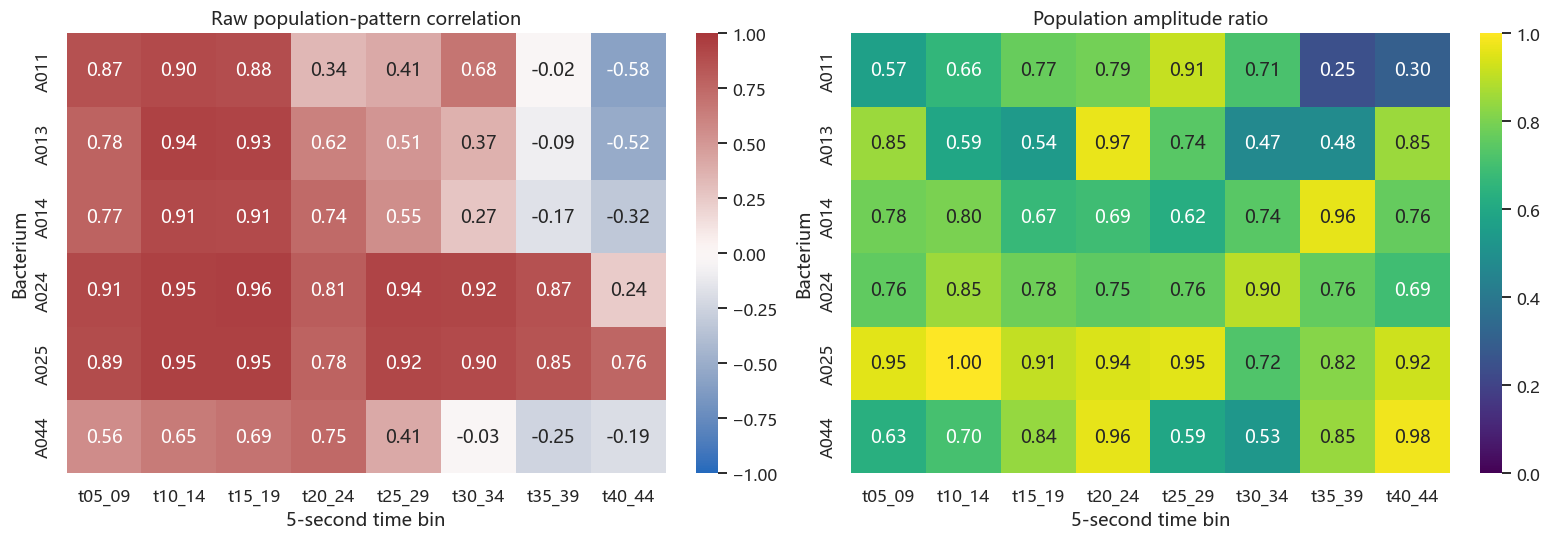

In [4]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 4.8),
    constrained_layout=True,
)

plot_definitions = [
    (
        "raw_pearson_r",
        "Raw population-pattern correlation",
        "vlag",
        -1,
        1,
    ),
    (
        "amplitude_ratio",
        "Population amplitude ratio",
        "viridis",
        0,
        1,
    ),
]

for ax, (metric, title, cmap, minimum, maximum) in zip(
    axes, plot_definitions
):
    matrix = (
        bin_reproducibility.pivot(
            index="sample_id",
            columns="time_bin",
            values=metric,
        )
        .reindex(
            index=REPEATED_SAMPLES,
            columns=time_bin_order,
        )
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        vmin=minimum,
        vmax=maximum,
        center=0 if minimum == -1 else None,
        cmap=cmap,
        linewidths=0,
        ax=ax,
    )

    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel("5-second time bin")
    ax.set_ylabel("Bacterium")

plt.show()

Observation:
1. 从raw bin correlation结果上看，刺激期间以及刺激后直到t25-t29，相似度显然比最后几个bin高
2. A024 A025的日期间差异较小
4. population amplitude 反映了整体响应强度的差异，但强度在实验时很容易受到光漂白等影响，属于系统误差比较大的量

Question：
如果不分bin，直接用full trace的correlation，相似性如何

In [5]:
# No-bin full-trace correlation
# 使用 5–44 s 的全部 40 个 time point，不进行时间分 bin

UNBINNED_TIME_POINTS = list(range(5, 19))
MIN_SHARED_FEATURES = 4
BOOTSTRAP_CHUNK_SIZE = 200

unbinned_columns = pd.MultiIndex.from_product(
    [class_order, UNBINNED_TIME_POINTS],
    names=["neuron_class", "time_point"],
)

unbinned_data = individual_trace.loc[
    individual_trace["time_point"].isin(UNBINNED_TIME_POINTS)
].copy()

trace_count = (
    unbinned_data.groupby(
        [
            "sample_id",
            "date",
            "worm_key",
            "neuron_class",
        ],
        observed=True,
    )["time_point"]
    .nunique()
)

if not trace_count.eq(len(UNBINNED_TIME_POINTS)).all():
    raise ValueError(
        "At least one individual-neuron trace is missing time points"
    )

# individual × (neuron class × time point)
feature_unbinned = (
    unbinned_data.pivot(
        index=["sample_id", "date", "worm_key"],
        columns=["neuron_class", "time_point"],
        values="delta_F_over_F0",
    )
    .reindex(columns=unbinned_columns)
)

# 每个 sample-date 对 individual 等权平均
centroid_unbinned = feature_unbinned.groupby(
    level=["sample_id", "date"]
).mean()


def bootstrap_centroids_chunked(
    values,
    indices,
    chunk_size=BOOTSTRAP_CHUNK_SIZE,
):
    """Bootstrap individual-level centroid，分块计算以降低内存占用。"""
    values = np.asarray(values, dtype=float)

    output = np.empty(
        (len(indices), values.shape[1]),
        dtype=float,
    )

    for start in range(0, len(indices), chunk_size):
        stop = min(start + chunk_size, len(indices))

        sampled = values[indices[start:stop]]
        valid = np.isfinite(sampled)

        totals = np.where(valid, sampled, 0).sum(axis=1)
        counts = valid.sum(axis=1)

        output[start:stop] = np.divide(
            totals,
            counts,
            out=np.full(totals.shape, np.nan),
            where=counts > 0,
        )

    return output


full_trace_results = []

for sample_id in REPEATED_SAMPLES:
    dates = sorted(
        centroid_unbinned.loc[sample_id].index.unique()
    )

    if len(dates) != 2:
        raise ValueError(
            f"{sample_id} occurs on {len(dates)} dates, not 2"
        )

    date_a, date_b = dates

    raw_a = (
        centroid_unbinned.loc[(sample_id, date_a)]
        .reindex(unbinned_columns)
        .to_numpy(dtype=float)
    )

    raw_b = (
        centroid_unbinned.loc[(sample_id, date_b)]
        .reindex(unbinned_columns)
        .to_numpy(dtype=float)
    )

    raw_valid = np.isfinite(raw_a) & np.isfinite(raw_b)

    raw_pearson = safe_pearson(
        raw_a,
        raw_b,
        min_values=MIN_SHARED_FEATURES,
    )

    if raw_valid.sum() >= MIN_SHARED_FEATURES:
        raw_spearman = float(
            spearmanr(
                raw_a[raw_valid],
                raw_b[raw_valid],
            )[0]
        )
    else:
        raw_spearman = np.nan

    raw_matrix_a = (
        feature_unbinned.xs(
            (sample_id, date_a),
            level=["sample_id", "date"],
        )
        .reindex(columns=unbinned_columns)
        .to_numpy(dtype=float)
    )

    raw_matrix_b = (
        feature_unbinned.xs(
            (sample_id, date_b),
            level=["sample_id", "date"],
        )
        .reindex(columns=unbinned_columns)
        .to_numpy(dtype=float)
    )

    seed_text = f"{sample_id}-full-trace"
    seed_offset = sum(
        (index + 1) * ord(character)
        for index, character in enumerate(seed_text)
    )

    rng = np.random.default_rng(SEED + seed_offset)

    indices_a = rng.integers(
        0,
        len(raw_matrix_a),
        size=(N_BOOTSTRAPS, len(raw_matrix_a)),
    )

    indices_b = rng.integers(
        0,
        len(raw_matrix_b),
        size=(N_BOOTSTRAPS, len(raw_matrix_b)),
    )

    bootstrap_a = bootstrap_centroids_chunked(
        raw_matrix_a,
        indices_a,
    )

    bootstrap_b = bootstrap_centroids_chunked(
        raw_matrix_b,
        indices_b,
    )

    bootstrap_correlations = [
        safe_pearson(
            bootstrap_a[index],
            bootstrap_b[index],
            min_values=MIN_SHARED_FEATURES,
        )
        for index in range(N_BOOTSTRAPS)
    ]

    (
        r_ci_low,
        r_bootstrap_median,
        r_ci_high,
        n_bootstrap_valid,
    ) = confidence_interval(bootstrap_correlations)

    full_trace_results.append(
        {
            "sample_id": sample_id,
            "date_a": date_a,
            "date_b": date_b,
            "n_shared_features": int(raw_valid.sum()),
            "raw_pearson_r": raw_pearson,
            "raw_spearman_r": raw_spearman,
            "raw_r_ci_low": r_ci_low,
            "raw_r_bootstrap_median": r_bootstrap_median,
            "raw_r_ci_high": r_ci_high,
            "n_bootstrap_valid": n_bootstrap_valid,
        }
    )

full_trace_reproducibility = (
    pd.DataFrame(full_trace_results)
    .sort_values("sample_id")
    .reset_index(drop=True)
)

display(full_trace_reproducibility.round(3))

,sample_id,date_a,date_b,n_shared_features,raw_pearson_r,raw_spearman_r,raw_r_ci_low,raw_r_bootstrap_median,raw_r_ci_high,n_bootstrap_valid
0,A011,20260429,20260520,182,0.888,0.899,0.696,0.855,0.926,2000
1,A013,20260414,20260601,182,0.914,0.867,0.712,0.867,0.915,2000
2,A014,20260414,20260601,182,0.884,0.831,0.616,0.844,0.894,2000
3,A024,20260414,20260601,182,0.939,0.683,0.819,0.920,0.960,2000
4,A025,20260331,20260414,182,0.945,0.844,0.819,0.925,0.957,2000
5,A044,20260414,20260429,182,0.653,0.709,0.456,0.631,0.741,2000


Observation:
1. 分bin与raw trace都表现出 A025 A025最好，A044最差
2. 5-30明显比30-45的重复性好，后期噪声可能较大

Question:
当前分bin以及boostrap都是以individual为单位，而individual的数量大多再4-7之间，数量太少，而若以trial为单位，重复数量会比较多，但每个individual的权重可能不一样

以trial作为单位，而不是individual，看是否与individual的结果相同

,sample_id,date_a,date_b,time_bin,n_animals_a,n_animals_b,n_trials_a,n_trials_b,n_shared_classes,raw_pearson_r,raw_r_ci_low,raw_r_ci_high,amplitude_ratio,amplitude_ci_low,amplitude_ci_high,n_bootstrap_valid
0,A011,20260429,20260520,t05_09,7,7,28,31,13,0.880,0.680,0.905,0.563,0.405,0.861,2000
1,A011,20260429,20260520,t10_14,7,7,28,31,13,0.908,0.718,0.954,0.659,0.522,0.855,2000
2,A011,20260429,20260520,t15_19,7,7,28,31,13,0.887,0.702,0.931,0.767,0.643,0.951,2000
3,A011,20260429,20260520,t20_24,7,7,28,31,13,0.331,0.006,0.635,0.786,0.630,0.976,2000
4,A011,20260429,20260520,t25_29,7,7,28,31,13,0.390,-0.261,0.911,0.903,0.652,0.994,2000
5,A011,20260429,20260520,t30_34,7,7,28,31,13,0.677,-0.207,0.825,0.724,0.372,0.975,2000
6,A011,20260429,20260520,t35_39,7,7,28,31,13,0.101,-0.285,0.382,0.246,0.139,0.741,2000
7,A011,20260429,20260520,t40_44,7,7,28,31,13,-0.513,-0.696,0.198,0.283,0.209,0.602,2000
8,A013,20260414,20260601,t05_09,5,6,22,28,13,0.849,0.383,0.892,0.903,0.557,0.994,2000
9,A013,20260414,20260601,t10_14,5,6,22,28,13,0.936,0.781,0.950,0.569,0.474,0.749,2000


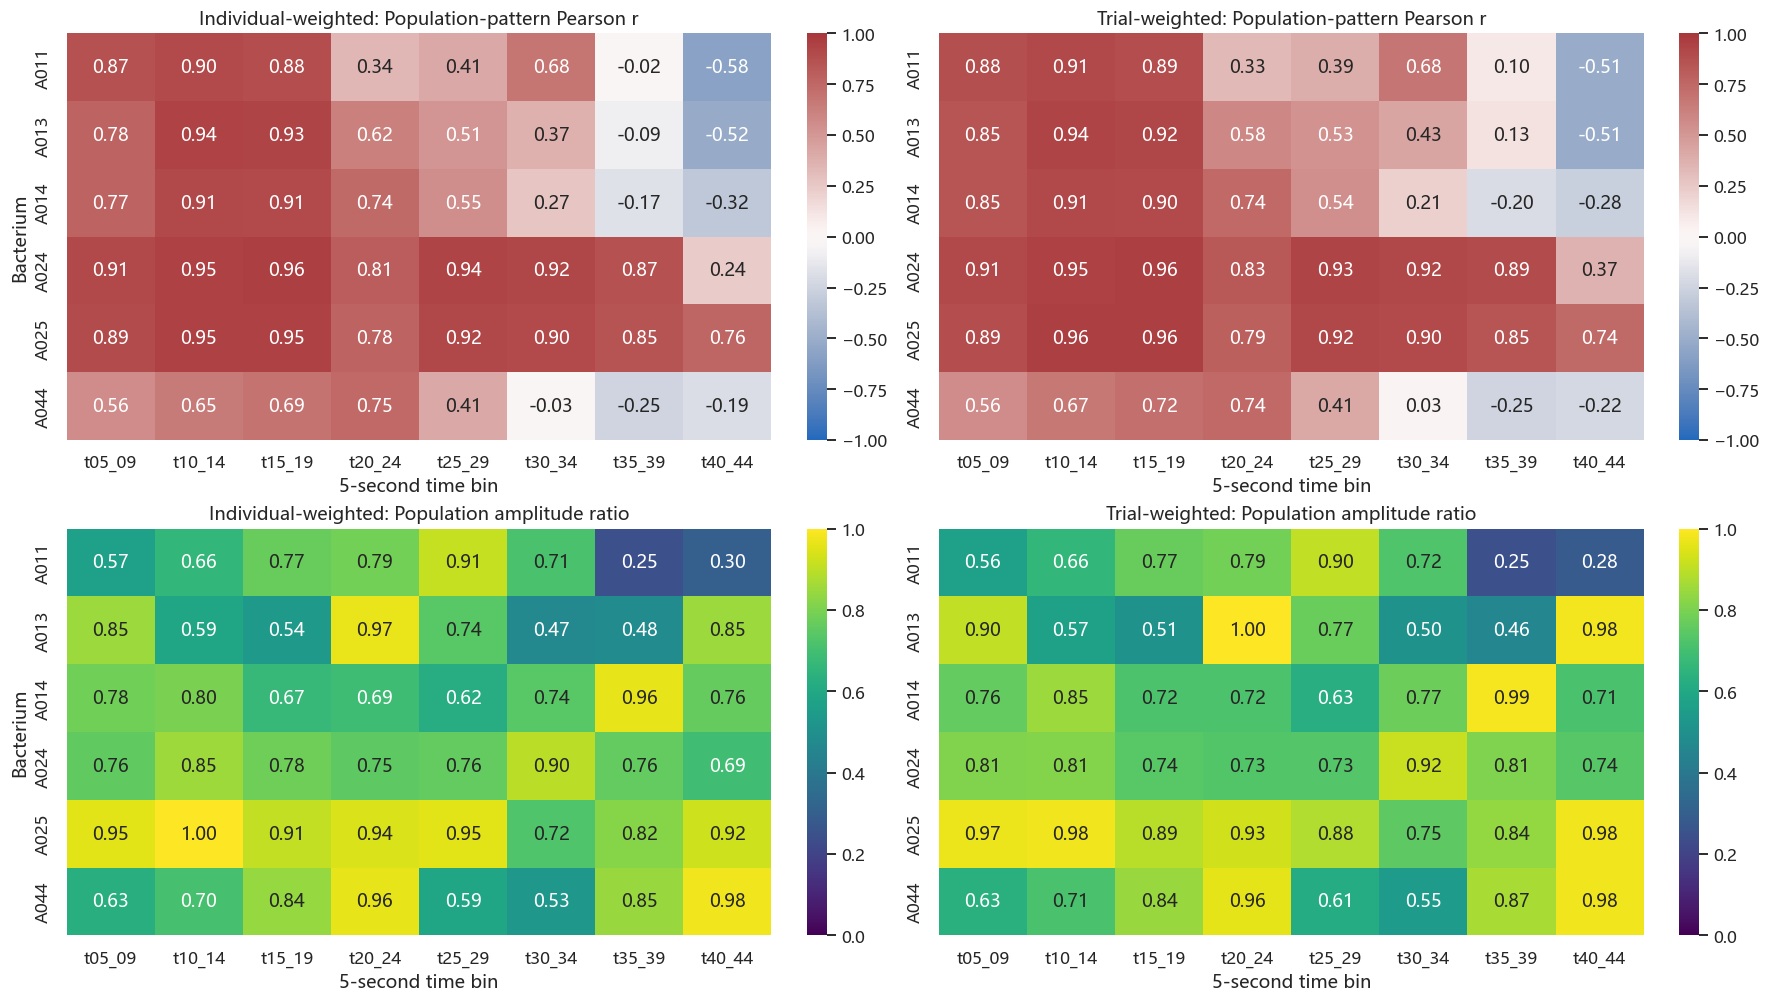

In [6]:
# Trial-level 5-second responses: one row per trial × neuron class × bin.
trial_binned = (
    trial_trace.loc[
        trial_trace["time_point"].isin(time_bin_by_point)
    ]
    .assign(
        time_bin=lambda data: data["time_point"].map(
            time_bin_by_point
        )
    )
    .groupby(
        [
            "sample_id", "date", "worm_key", "segment_index",
            "neuron_class", "time_bin",
        ],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
    .rename(columns={"delta_F_over_F0": "response"})
)

trial_feature = (
    trial_binned.pivot(
        index=["sample_id", "date", "worm_key", "segment_index"],
        columns=["neuron_class", "time_bin"],
        values="response",
    )
    .reindex(columns=expected_columns)
)


def cluster_bootstrap_trial_centroid(trials, rng):
    """Resample animals; retain all observed trials of each drawn animal."""
    worm_ids = trials.index.get_level_values("worm_key").unique()
    totals = []
    counts = []

    for worm_key in worm_ids:
        values = trials.xs(
            worm_key, level="worm_key"
        ).to_numpy(dtype=float)
        valid = np.isfinite(values)
        totals.append(np.where(valid, values, 0.0).sum(axis=0))
        counts.append(valid.sum(axis=0))

    totals = np.asarray(totals)
    counts = np.asarray(counts)
    n_worms = len(worm_ids)

    draws = rng.integers(
        0, n_worms, size=(N_BOOTSTRAPS, n_worms)
    )
    sampled_totals = totals[draws].sum(axis=1)
    sampled_counts = counts[draws].sum(axis=1)

    return np.divide(
        sampled_totals,
        sampled_counts,
        out=np.full(sampled_totals.shape, np.nan),
        where=sampled_counts > 0,
    )


trial_results = []

for sample_id in REPEATED_SAMPLES:
    dates = sorted(
        trial_feature.loc[sample_id]
        .index.get_level_values("date")
        .unique()
    )
    if len(dates) != 2:
        raise ValueError(
            f"{sample_id}: expected two dates, found {dates}"
        )

    date_a, date_b = dates

    for time_bin in time_bin_order:
        columns = [
            (neuron_class, time_bin)
            for neuron_class in class_order
        ]

        trials_a = trial_feature.xs(
            (sample_id, date_a),
            level=["sample_id", "date"],
        ).reindex(columns=columns)
        trials_b = trial_feature.xs(
            (sample_id, date_b),
            level=["sample_id", "date"],
        ).reindex(columns=columns)

        # Each observed trial has equal weight in the date centroid.
        mean_a = trials_a.mean(axis=0).to_numpy(dtype=float)
        mean_b = trials_b.mean(axis=0).to_numpy(dtype=float)

        seed_text = f"trial-{sample_id}-{time_bin}"
        seed_offset = sum(
            (index + 1) * ord(character)
            for index, character in enumerate(seed_text)
        )
        rng = np.random.default_rng(SEED + seed_offset)

        boot_a = cluster_bootstrap_trial_centroid(trials_a, rng)
        boot_b = cluster_bootstrap_trial_centroid(trials_b, rng)

        bootstrap_r = [
            safe_pearson(first, second)
            for first, second in zip(boot_a, boot_b)
        ]
        bootstrap_amplitude = [
            amplitude_ratio(first, second)
            for first, second in zip(boot_a, boot_b)
        ]

        r_low, _, r_high, r_valid = confidence_interval(
            bootstrap_r
        )
        amp_low, _, amp_high, amp_valid = confidence_interval(
            bootstrap_amplitude
        )

        trial_results.append({
            "sample_id": sample_id,
            "date_a": date_a,
            "date_b": date_b,
            "time_bin": time_bin,
            "n_animals_a": trials_a.index.get_level_values(
                "worm_key"
            ).nunique(),
            "n_animals_b": trials_b.index.get_level_values(
                "worm_key"
            ).nunique(),
            "n_trials_a": len(trials_a),
            "n_trials_b": len(trials_b),
            "n_shared_classes": int(
                (np.isfinite(mean_a) & np.isfinite(mean_b)).sum()
            ),
            "raw_pearson_r": safe_pearson(mean_a, mean_b),
            "raw_r_ci_low": r_low,
            "raw_r_ci_high": r_high,
            "amplitude_ratio": amplitude_ratio(mean_a, mean_b),
            "amplitude_ci_low": amp_low,
            "amplitude_ci_high": amp_high,
            "n_bootstrap_valid": min(r_valid, amp_valid),
        })

trial_reproducibility = (
    pd.DataFrame(trial_results)
    .sort_values(["sample_id", "time_bin"])
    .reset_index(drop=True)
)

display(trial_reproducibility.round(3))

fig, axes = plt.subplots(
    2, 2, figsize=(16, 9), constrained_layout=True
)

for column, (data, unit_label) in enumerate([
    (bin_reproducibility, "Individual-weighted"),
    (trial_reproducibility, "Trial-weighted"),
]):
    for row, (metric, metric_label, cmap, lower, upper) in enumerate([
        ("raw_pearson_r", "Population-pattern Pearson r",
         "vlag", -1, 1),
        ("amplitude_ratio", "Population amplitude ratio",
         "viridis", 0, 1),
    ]):
        matrix = (
            data.pivot(
                index="sample_id",
                columns="time_bin",
                values=metric,
            )
            .reindex(
                index=REPEATED_SAMPLES,
                columns=time_bin_order,
            )
        )

        ax = axes[row, column]
        sns.heatmap(
            matrix,
            annot=True,
            fmt=".2f",
            vmin=lower,
            vmax=upper,
            center=0 if lower == -1 else None,
            cmap=cmap,
            linewidths=0,
            ax=ax,
        )
        ax.grid(False)
        ax.set_title(f"{unit_label}: {metric_label}")
        ax.set_xlabel("5-second time bin")
        ax.set_ylabel("Bacterium" if column == 0 else "")

plt.show()

Observation
- trial为单位以及individual为单位，结果相似，trial数量少的individual意味着实验过程中成像效果一般，所以以trial为基本单位

In [8]:
FIGURE_DIR = (
    ROOT / "output" / "jupyter-notebook"
    / "02_reproducibility_figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CURVE_BOOTSTRAPS = 2000
PLOT_SAMPLES = REPEATED_SAMPLES  # Use ["A025"] to inspect one sample first.
SHOW_INDIVIDUALS = True

time_points = np.arange(45)
rng = np.random.default_rng(SEED)

plt.rcParams["axes.grid"] = False


def get_individual_curves(sample_id, date, neuron_class):
    selected = individual_trace.loc[
        (individual_trace["sample_id"] == sample_id)
        & (individual_trace["date"] == date)
        & (individual_trace["neuron_class"] == neuron_class)
    ]

    curves = selected.pivot(
        index="worm_key",
        columns="time_point",
        values="delta_F_over_F0",
    ).reindex(columns=time_points)

    if curves.empty:
        return None

    if curves.isna().any().any():
        raise ValueError(
            f"Incomplete trace: {sample_id}, {date}, {neuron_class}"
        )

    return curves.to_numpy(dtype=float)


def bootstrap_mean_curve(curves):
    n_individuals = len(curves)
    indices = rng.integers(
        0,
        n_individuals,
        size=(CURVE_BOOTSTRAPS, n_individuals),
    )

    bootstrap_means = curves[indices].mean(axis=1)
    observed_mean = curves.mean(axis=0)

    return observed_mean, bootstrap_means


for sample_id in PLOT_SAMPLES:
    dates = sorted(
        individual_trace.loc[
            individual_trace["sample_id"] == sample_id,
            "date",
        ].unique()
    )

    if len(dates) != 2:
        raise ValueError(
            f"{sample_id}: expected two dates, found {dates}"
        )

    date_a, date_b = dates

    fig, axes = plt.subplots(
        len(class_order),
        2,
        figsize=(15, 2.35 * len(class_order)),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )

    fig.suptitle(
        f"{sample_id}: individual-averaged responses across dates",
        fontsize=15,
    )

    for row, neuron_class in enumerate(class_order):
        ax_mean, ax_difference = axes[row]

        curves_a = get_individual_curves(
            sample_id, date_a, neuron_class
        )
        curves_b = get_individual_curves(
            sample_id, date_b, neuron_class
        )

        if curves_a is None or curves_b is None:
            ax_mean.text(
                0.5, 0.5,
                "Neuron unavailable on one date",
                ha="center",
                va="center",
                transform=ax_mean.transAxes,
            )
            ax_difference.axis("off")
            continue

        mean_a, boot_a = bootstrap_mean_curve(curves_a)
        mean_b, boot_b = bootstrap_mean_curve(curves_b)

        ci_a = np.quantile(boot_a, [0.025, 0.975], axis=0)
        ci_b = np.quantile(boot_b, [0.025, 0.975], axis=0)

        difference = mean_b - mean_a
        boot_difference = boot_b - boot_a
        ci_difference = np.quantile(
            boot_difference,
            [0.025, 0.975],
            axis=0,
        )

        if SHOW_INDIVIDUALS:
            for curve in curves_a:
                ax_mean.plot(
                    time_points, curve,
                    color="C0",
                    alpha=0.12,
                    linewidth=0.8,
                )
            for curve in curves_b:
                ax_mean.plot(
                    time_points, curve,
                    color="C1",
                    alpha=0.12,
                    linewidth=0.8,
                )

        ax_mean.plot(
            time_points, mean_a,
            color="C0",
            linewidth=1.8,
            label=f"{date_a} (n={len(curves_a)})",
        )
        ax_mean.fill_between(
            time_points, ci_a[0], ci_a[1],
            color="C0",
            alpha=0.22,
        )

        ax_mean.plot(
            time_points, mean_b,
            color="C1",
            linewidth=1.8,
            label=f"{date_b} (n={len(curves_b)})",
        )
        ax_mean.fill_between(
            time_points, ci_b[0], ci_b[1],
            color="C1",
            alpha=0.22,
        )

        ax_difference.plot(
            time_points, difference,
            color="C3",
            linewidth=1.8,
        )
        ax_difference.fill_between(
            time_points,
            ci_difference[0],
            ci_difference[1],
            color="C3",
            alpha=0.22,
        )

        for ax in (ax_mean, ax_difference):
            ax.grid(False)
            ax.axhline(0, color="0.4", linewidth=0.8)
            ax.axvspan(5, 15, color="C2", alpha=0.10)
            ax.axvline(5, color="C2", linestyle="--", linewidth=0.8)
            ax.axvline(15, color="C2", linestyle="--", linewidth=0.8)
            ax.set_xlim(0, 44)

        ax_mean.set_ylabel(f"{neuron_class}\nΔF/F0")
        ax_difference.set_ylabel("Difference in ΔF/F0")

        if row == 0:
            ax_mean.set_title("Mean response by date")
            ax_difference.set_title(
                f"Difference: {date_b} − {date_a}"
            )
            ax_mean.legend(frameon=False, fontsize=9)

    axes[-1, 0].set_xlabel("Time (s)")
    axes[-1, 1].set_xlabel("Time (s)")

    channel_mode = "pooled_lr" if POOL_BILATERAL else "separate_lr"
    figure_path = FIGURE_DIR / (
        f"{sample_id}_{date_a}_vs_{date_b}_{channel_mode}_raw_curves.png"
    )

    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {figure_path}")

Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\A011_20260429_vs_20260520_pooled_lr_raw_curves.png
Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\A013_20260414_vs_20260601_pooled_lr_raw_curves.png
Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\A014_20260414_vs_20260601_pooled_lr_raw_curves.png
Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\A024_20260414_vs_20260601_pooled_lr_raw_curves.png
Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\A025_20260331_vs_20260414_pooled_lr_raw_curves.png
Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\A044_20260414_vs_20260429_pooled_lr_raw_curves.png


Observation:

不同date代表不同batch，batch间样本的培养存在不可避免地差异，chip environment以及投递条件已经尽可能保持相同
在目前仅有的6个across batch的bacteria中，
A011 AWA individual间存在差异，且两个date的response type明显不同
A013 两个date并未有太大不一致，但AWCON存在较大的individual variability
A014 整体趋势类似A013，问题也相同
A024 ASER AWCON AWCOFF表现出不一致性，ASER的response type甚至发生变化
A025 ASH的response type发生变化
A044 ASH ADF的response type发生改变

Question
分bin降采样得到的相似性，是否忠诚于原始trace？

In [10]:
HEATMAP_DIR = (
    ROOT / "output" / "jupyter-notebook"
    / "02_reproducibility_figures" / "heatmaps"
)
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

raw_times = np.arange(45)
bin_labels = [
    f"{min(TIME_BINS[name]):02d}–{max(TIME_BINS[name]):02d}"
    for name in time_bin_order
]

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#dddddd")  # Missing neuron classes, not zero responses.


def date_mean_matrix(
    data, sample_id, date, time_column, value_column, time_order
):
    selected = data.loc[
        data["sample_id"].eq(sample_id)
        & data["date"].eq(date)
    ]

    return (
        selected.groupby(
            ["neuron_class", time_column],
            observed=True,
        )[value_column]
        .mean()
        .unstack(time_column)
        .reindex(index=class_order, columns=time_order)
        .to_numpy(dtype=float)
    )


for sample_id in REPEATED_SAMPLES:
    dates = sorted(
        individual_trace.loc[
            individual_trace["sample_id"].eq(sample_id),
            "date",
        ].unique()
    )
    if len(dates) != 2:
        raise ValueError(
            f"{sample_id}: expected two dates, found {dates}"
        )

    date_a, date_b = dates

    raw_a = date_mean_matrix(
        individual_trace, sample_id, date_a,
        "time_point", "delta_F_over_F0", raw_times,
    )
    raw_b = date_mean_matrix(
        individual_trace, sample_id, date_b,
        "time_point", "delta_F_over_F0", raw_times,
    )
    bin_a = date_mean_matrix(
        individual_binned, sample_id, date_a,
        "time_bin", "response", time_bin_order,
    )
    bin_b = date_mean_matrix(
        individual_binned, sample_id, date_b,
        "time_bin", "response", time_bin_order,
    )

    panels = [
        (date_a, raw_a, bin_a),
        (date_b, raw_b, bin_b),
        (f"{date_b} − {date_a}", raw_b - raw_a, bin_b - bin_a),
    ]

    # One unscaled, symmetric color range for all six panels of this sample.
    all_values = np.concatenate([
        values[np.isfinite(values)]
        for _, raw_values, bin_values in panels
        for values in (raw_values, bin_values)
    ])
    color_limit = (
        max(float(np.max(np.abs(all_values))), 1e-6)
        if all_values.size else 1.0
    )

    count_a = class_coverage.loc[
        (sample_id, date_a)
    ].reindex(class_order, fill_value=0)
    count_b = class_coverage.loc[
        (sample_id, date_b)
    ].reindex(class_order, fill_value=0)

    row_labels = [
        [
            f"{neuron} (n={int(count_a[neuron])})"
            for neuron in class_order
        ],
        [
            f"{neuron} (n={int(count_b[neuron])})"
            for neuron in class_order
        ],
        [
            f"{neuron} (n={int(count_a[neuron])}/{int(count_b[neuron])})"
            for neuron in class_order
        ],
    ]

    fig, axes = plt.subplots(
        3, 2,
        figsize=(17, 12),
        gridspec_kw={"width_ratios": [2.4, 1]},
        constrained_layout=True,
    )

    fig.suptitle(
        f"{sample_id}: raw and 5-second binned responses"
        "\nStimulus: 5–14 s; color scale in ΔF/F₀",
        fontsize=14,
    )

    for row, (row_name, raw_values, bin_values) in enumerate(panels):
        for column, values in enumerate((raw_values, bin_values)):
            ax = axes[row, column]
            image = ax.imshow(
                values,
                cmap=cmap,
                vmin=-color_limit,
                vmax=color_limit,
                origin="upper",
                aspect="auto",
                interpolation="nearest",
            )

            ax.grid(False)
            ax.set_yticks(np.arange(len(class_order)))
            if column == 0:
                ax.set_yticklabels(row_labels[row], fontsize=9)
                ax.set_ylabel(row_name)
                ax.set_xticks([0, 5, 10, 15, 20, 25, 30, 35, 40, 44])
            else:
                ax.set_yticklabels([])
                ax.set_xticks(np.arange(len(time_bin_order)))
                ax.set_xticklabels(
                    bin_labels, rotation=45, ha="right"
                )

            if row < 2:
                ax.tick_params(axis="x", labelbottom=False)
            else:
                ax.set_xlabel(
                    "Time (s)" if column == 0 else "5-second bin (s)"
                )

    axes[0, 0].set_title("45 time points")
    axes[0, 1].set_title("8 bin means")

    fig.colorbar(
        image,
        ax=axes.ravel().tolist(),
        label="ΔF/F₀",
        shrink=0.8,
        pad=0.02,
    )

    channel_mode = (
        "pooled_lr" if POOL_BILATERAL else "separate_lr"
    )
    figure_path = HEATMAP_DIR / (
        f"{sample_id}_{date_a}_vs_{date_b}_"
        f"{channel_mode}_raw_and_5s_heatmaps.png"
    )
    fig.savefig(figure_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {figure_path}")

C:\Users\Administrator\AppData\Local\Temp\ipykernel_56324\3501016980.py:171: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=180, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\heatmaps\A011_20260429_vs_20260520_pooled_lr_raw_and_5s_heatmaps.png


C:\Users\Administrator\AppData\Local\Temp\ipykernel_56324\3501016980.py:171: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=180, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\heatmaps\A013_20260414_vs_20260601_pooled_lr_raw_and_5s_heatmaps.png


C:\Users\Administrator\AppData\Local\Temp\ipykernel_56324\3501016980.py:171: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=180, bbox_inches="tight")


...

Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\heatmaps\A024_20260414_vs_20260601_pooled_lr_raw_and_5s_heatmaps.png


C:\Users\Administrator\AppData\Local\Temp\ipykernel_56324\3501016980.py:171: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=180, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\heatmaps\A025_20260331_vs_20260414_pooled_lr_raw_and_5s_heatmaps.png


C:\Users\Administrator\AppData\Local\Temp\ipykernel_56324\3501016980.py:171: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=180, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\heatmaps\A044_20260414_vs_20260429_pooled_lr_raw_and_5s_heatmaps.png


Observation:
分bin可以在一定程度保留局部特征,说明即使降采样，时间特征依然保留

Question：
对于没有重复日期的bac，评估其reproducibility可以通过half split完成，之前的half split我采用trials分半，即将每一个trial当成一个独立的部分，然而individual之间存在variability，甚至会超过单个individual 所有trials之间的变异，这里采用individual作为unit来分析
可以构造一个response heatmap profile，对于reproducibility的展示(可将其作为实验的panel1)，可以构思4张子图
A 来展示response profile，由于neuronxbacteira的组合比较多，采用heatmap的视觉观感更简洁，也更能捕捉到response 存在一些特征，由于分bin降采样并不会损失基本的时间信息，这里仍然采用分bin的结果，这样压缩了时间，视觉观感更好

In [ ]:
# 没有time bin的版本
if not POOL_BILATERAL:
    raise ValueError(
        "Panel A uses 13 pooled neuron classes. "
        "Set POOL_BILATERAL=True in cell 3."
    )

ATLAS_TIME_POINTS = np.arange(5, 45)
ATLAS_CLASSES = [
    *BILATERAL_CLASSES,
    "ASEL",
    "ASER",
    "AWCON",
    "AWCOFF",
]
COLOR_LIMIT = 1.0  # Display-only cap; use None for the full range.
N_PAGES = 4

ATLAS_DIR = (
    ROOT / "output" / "jupyter-notebook"
    / "02_reproducibility_figures" / "response_atlas"
)
ATLAS_DIR.mkdir(parents=True, exist_ok=True)

# Cell 3's df contains only six repeated bacteria, so reload all samples.
source_columns = [
    "date",
    "worm_key",
    "segment_index",
    "stim_name",
    "neuron",
    "time_point",
    "delta_F_over_F0",
]

all_source = pd.read_parquet(
    ROOT / "data" / "106bac.parquet",
    columns=source_columns,
)
all_source["sample_id"] = all_source["stim_name"].str.extract(
    r"^(A\d{3})",
    expand=False,
)
all_source["date"] = all_source["date"].astype(str)

all_source = all_source.loc[
    all_source["sample_id"].notna()
    & ~all_source["neuron"].isin(DROP_NEURONS)
    & all_source["time_point"].isin(ATLAS_TIME_POINTS)
].copy()

all_source["neuron_class"] = (
    all_source["neuron"]
    .map(neuron_to_class)
    .fillna(all_source["neuron"])
)

unexpected_classes = (
    set(all_source["neuron_class"]) - set(ATLAS_CLASSES)
)
if unexpected_classes:
    raise ValueError(
        f"Unexpected neuron classes: {sorted(unexpected_classes)}"
    )

# First average L/R within each trial and time point.
all_trial_trace = (
    all_source.groupby(
        [
            "sample_id", "date", "worm_key", "segment_index",
            "neuron_class", "time_point",
        ],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
)

# Then average repeated trials within each animal.
all_individual_trace = (
    all_trial_trace.groupby(
        [
            "sample_id", "date", "worm_key",
            "neuron_class", "time_point",
        ],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
)

# Each animal contributes equally to its sample-date mean.
all_mean_matrix = (
    all_individual_trace.groupby(
        ["sample_id", "date", "neuron_class", "time_point"],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
    .pivot(
        index=["sample_id", "date"],
        columns=["neuron_class", "time_point"],
        values="delta_F_over_F0",
    )
    .sort_index()
    .reindex(
        columns=pd.MultiIndex.from_product(
            [ATLAS_CLASSES, ATLAS_TIME_POINTS],
            names=["neuron_class", "time_point"],
        )
    )
)

atlas_rows = all_mean_matrix.index
row_labels = [
    f"{sample_id}  {date}"
    for sample_id, date in atlas_rows
]

# Keep neuron-specific animal counts for Panel B and coverage checks.
all_class_coverage = (
    all_individual_trace.groupby(
        ["sample_id", "date", "neuron_class"],
        observed=True,
    )["worm_key"]
    .nunique()
    .unstack("neuron_class", fill_value=0)
    .reindex(index=atlas_rows, columns=ATLAS_CLASSES)
)
coverage_path = ATLAS_DIR / "individual_count_by_class.csv"
all_class_coverage.to_csv(coverage_path)

del all_source, all_trial_trace

finite_values = all_mean_matrix.to_numpy(dtype=float)
finite_values = finite_values[np.isfinite(finite_values)]
if finite_values.size == 0:
    raise ValueError("No finite response values found")

color_limit = (
    float(np.max(np.abs(finite_values)))
    if COLOR_LIMIT is None
    else float(COLOR_LIMIT)
)
if color_limit <= 0:
    raise ValueError("COLOR_LIMIT must be positive")

clipped_fraction = np.mean(
    np.abs(finite_values) > color_limit
)

print(
    f"{atlas_rows.get_level_values('sample_id').nunique()} bacteria; "
    f"{len(atlas_rows)} sample-date rows; "
    f"{len(ATLAS_CLASSES)} neuron classes; "
    f"{len(ATLAS_TIME_POINTS)} time points"
)
print(
    f"Animal count by sample-date-class: "
    f"{all_class_coverage.min().min()}–"
    f"{all_class_coverage.max().max()}"
)
print(
    f"Display range: ±{color_limit:.3f} ΔF/F₀; "
    f"saturated values: {clipped_fraction:.2%}"
)
print(f"Coverage table: {coverage_path}")

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#dddddd")

tick_positions = [0, 5, 10, 15, 20, 25, 30, 35, 39]
page_groups = np.array_split(ATLAS_CLASSES, N_PAGES)

for page_number, page_classes in enumerate(page_groups, start=1):
    fig, ax_grid = plt.subplots(
        1,
        len(page_classes),
        figsize=(
            5.2 * len(page_classes) + 2,
            max(14, 0.24 * len(atlas_rows)),
        ),
        sharey=True,
        squeeze=False,
        constrained_layout=True,
    )
    axes = ax_grid[0]

    fig.suptitle(
        f"Mean response atlas — page {page_number}/{N_PAGES}\n"
        "Animal-weighted ΔF/F₀; stimulus 5–14 s; "
        "dashed line marks stimulus offset",
        fontsize=14,
    )

    for column_number, neuron_class in enumerate(page_classes):
        ax = axes[column_number]
        values = all_mean_matrix.xs(
            neuron_class,
            axis=1,
            level="neuron_class",
        ).to_numpy(dtype=float)

        image = ax.imshow(
            values,
            cmap=cmap,
            vmin=-color_limit,
            vmax=color_limit,
            origin="upper",
            aspect="auto",
            interpolation="nearest",
        )

        # Column 9 is t=14; column 10 is t=15.
        ax.axvline(
            9.5,
            color="0.2",
            linestyle="--",
            linewidth=0.8,
        )
        ax.grid(False)
        ax.set_title(neuron_class)
        ax.set_xlabel("Time (s)")
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(
            [ATLAS_TIME_POINTS[position] for position in tick_positions]
        )

        ax.set_yticks(np.arange(len(atlas_rows)))
        ax.tick_params(
            axis="y",
            left=False,
            labelleft=(column_number == 0),
        )
        if column_number == 0:
            ax.set_yticklabels(row_labels, fontsize=6.5)
            ax.set_ylabel("Bacterium · date")

    fig.colorbar(
        image,
        ax=axes.tolist(),
        label="ΔF/F₀",
        extend="both" if COLOR_LIMIT is not None else "neither",
        shrink=0.75,
        pad=0.02,
    )

    figure_path = ATLAS_DIR / (
        f"mean_response_page_{page_number:02d}_pooled_lr.png"
    )
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {figure_path}")

106 bacteria; 112 sample-date rows; 13 neuron classes; 40 time points
Animal count by sample-date-class: 2–7
Display range: ±1.000 ΔF/F₀; saturated values: 0.81%
Coverage table: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\response_atlas\individual_count_by_class.csv


C:\Users\Administrator\AppData\Local\Temp\ipykernel_53200\627548760.py:251: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=150, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\response_atlas\mean_response_page_01_pooled_lr.png


C:\Users\Administrator\AppData\Local\Temp\ipykernel_53200\627548760.py:251: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=150, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\response_atlas\mean_response_page_02_pooled_lr.png


C:\Users\Administrator\AppData\Local\Temp\ipykernel_53200\627548760.py:251: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=150, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\response_atlas\mean_response_page_03_pooled_lr.png


C:\Users\Administrator\AppData\Local\Temp\ipykernel_53200\627548760.py:251: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  fig.savefig(figure_path, dpi=150, bbox_inches="tight")


Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\response_atlas\mean_response_page_04_pooled_lr.png


In [21]:
# Bin each animal's response before averaging animals.
ATLAS_BIN_ORDER = [
    f"{start:02d}-{start + 4:02d}"
    for start in range(5, 45, 5)
]
point_to_bin = {
    time_point: f"{start:02d}-{start + 4:02d}"
    for start in range(5, 45, 5)
    for time_point in range(start, start + 5)
}

all_individual_binned = (
    all_individual_trace
    .assign(
        time_bin=lambda data: data["time_point"].map(
            point_to_bin
        )
    )
    .groupby(
        [
            "sample_id", "date", "worm_key",
            "neuron_class", "time_bin",
        ],
        as_index=False,
        observed=True,
    )["delta_F_over_F0"]
    .mean()
    .rename(columns={"delta_F_over_F0": "dfof"})
)

bin_counts = (
    all_individual_binned.groupby(
        ["sample_id", "date", "worm_key", "neuron_class"],
        observed=True,
    )["time_bin"]
    .nunique()
)
if not bin_counts.eq(8).all():
    raise ValueError(
        "At least one animal-neuron response is missing a 5-second bin"
    )

# Date mean: each animal has equal weight.
all_mean_binned = (
    all_individual_binned.groupby(
        ["sample_id", "date", "neuron_class", "time_bin"],
        as_index=False,
        observed=True,
    )["dfof"]
    .mean()
    .pivot(
        index=["sample_id", "date"],
        columns=["neuron_class", "time_bin"],
        values="dfof",
    )
    .sort_index()
    .reindex(
        columns=pd.MultiIndex.from_product(
            [ATLAS_CLASSES, ATLAS_BIN_ORDER],
            names=["neuron_class", "time_bin"],
        )
    )
)

atlas_rows = all_mean_binned.index
row_labels = [
    f"{sample_id}  {date}"
    for sample_id, date in atlas_rows
]

all_class_coverage = (
    all_individual_binned.groupby(
        ["sample_id", "date", "neuron_class"],
        observed=True,
    )["worm_key"]
    .nunique()
    .unstack("neuron_class", fill_value=0)
    .reindex(index=atlas_rows, columns=ATLAS_CLASSES)
)
coverage_path = ATLAS_DIR / "individual_count_by_class.csv"
all_class_coverage.to_csv(coverage_path)


finite_values = all_mean_binned.to_numpy(dtype=float)
finite_values = finite_values[np.isfinite(finite_values)]
if finite_values.size == 0:
    raise ValueError("No finite binned responses found")

color_limit = (
    float(np.max(np.abs(finite_values)))
    if COLOR_LIMIT is None
    else float(COLOR_LIMIT)
)
if color_limit <= 0:
    raise ValueError("COLOR_LIMIT must be positive")

clipped_fraction = np.mean(
    np.abs(finite_values) > color_limit
)

print(
    f"{atlas_rows.get_level_values('sample_id').nunique()} bacteria; "
    f"{len(atlas_rows)} sample-date rows; "
    f"{len(ATLAS_CLASSES)} neuron classes; "
    f"{len(ATLAS_BIN_ORDER)} time bins"
)
print(
    f"Display range: ±{color_limit:.3f} dfof; "
    f"saturated values: {clipped_fraction:.2%}"
)
print(f"Coverage table: {coverage_path}")

cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad("#dddddd")

fig, ax_grid = plt.subplots(
    1,
    len(ATLAS_CLASSES),
    figsize=(36, max(14, 0.24 * len(atlas_rows))),
    sharey=True,
    squeeze=False,
    constrained_layout=True,
)
axes = ax_grid[0]

fig.suptitle(
    "Mean response atlas: 5-second bins\n"
    "Animal-weighted dfof; dashed line marks stimulus offset",
    fontsize=16,
)

for column_number, neuron_class in enumerate(ATLAS_CLASSES):
    ax = axes[column_number]

    values = all_mean_binned.xs(
        neuron_class,
        axis=1,
        level="neuron_class",
    ).to_numpy(dtype=float)

    image = ax.imshow(
        values,
        cmap=cmap,
        vmin=-color_limit,
        vmax=color_limit,
        origin="upper",
        aspect="auto",
        interpolation="nearest",
    )

    # Stimulus occupies bins 05-09 and 10-14.
    ax.axvline(
        1.5,
        color="0.2",
        linestyle="--",
        linewidth=0.8,
    )
    ax.grid(False)
    ax.set_title(neuron_class)
    ax.set_xticks(np.arange(len(ATLAS_BIN_ORDER)))
    ax.set_xticklabels(
        ATLAS_BIN_ORDER,
        rotation=90,
        fontsize=7,
    )

    ax.set_yticks(np.arange(len(atlas_rows)))
    ax.tick_params(
        axis="y",
        left=False,
        labelleft=(column_number == 0),
    )
    if column_number == 0:
        ax.set_yticklabels(row_labels, fontsize=6.5)
        ax.set_ylabel("Bacterium · date")

fig.supxlabel("Time bin (s)")
fig.colorbar(
    image,
    ax=axes.tolist(),
    label="dfof",
    extend="both" if COLOR_LIMIT is not None else "neither",
    shrink=0.75,
    pad=0.006,
)

figure_path = (
    ATLAS_DIR / "mean_response_all_neurons_5s_bins.png"
)
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Saved: {figure_path}")

106 bacteria; 112 sample-date rows; 13 neuron classes; 8 time bins
Display range: ±1.000 dfof; saturated values: 0.72%
Coverage table: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\response_atlas\individual_count_by_class.csv
Saved: H:\Process_temporary\WJH\bacteria_analysis\output\jupyter-notebook\02_reproducibility_figures\response_atlas\mean_response_all_neurons_5s_bins.png


Observation:
热图展示了整体的响应模式，但并未对重复性做比较好的描述；我们可以将date信息去掉，排序并修饰一下neuron之间的间隔，将该图作为整体profile的呈现

本来构造了一个C 其实是非负余弦相似度的平方 gain fitting 确实排除了一个整体正比例缩放的影响，但最终的标准化残差并不是一种独立于相似度的新证据，而是余弦相似度的另一种表达。

若定义实际响应大小之比为 $q_i=\frac{\|x_i\|}{\|\mu_{-i}\|}
=\frac{\mathrm{animal\ RMS}}{\mathrm{template\ RMS}}.$ 可得 $\boxed{g_i=q_i\sqrt{C_i}}$ 即响应大小之比相似时，gain与C其实等同

可以检查一下：低 \(C\) 是否主要出现在弱响应、参考动物少、覆盖神经元少的记录中；还是在响应清楚、参考充分的记录中也普遍存在？

在individual间存在variability时，群体平均响应仍然可以被稳定估计，以一个简化模型为例： $x_i=s+\epsilon_i,$ 其中s为群体响应期望，$epsilon_i$为individual间均值为0的分布方差，有 $\operatorname{Cov}(\bar x)=\frac{\operatorname{Cov}(\epsilon)}{n}.$ 由于后续分析采用 菌株的 population-average response，可以将当前探索的可视化问题改为：
> 同一天，用互不重叠的两组动物，能不能重建相近的群体响应图谱？

我们可以将主图改为“两组独立动物的平均图谱”，每个 菌株x日期 内，可以将individual分成A,B两组，可以画成两张上下对齐的热图，沿用菌株顺序, 13类神经元以及8个时间bin，使用同一个色标
旁边一张重复分半的汇总分布，为避免结果依赖某次分组，可以重复随机分半，例如 100 次。由于C为Cosine similarity的变换，这里直接定义cosine similarity：$s_i=\operatorname{cosine}(x_i,\mu_{-i})
=\frac{x_i^\top\mu_{-i}}
{\|x_i\|\|\mu_{-i}\|}.$ 从单只动物，变成后续真正使用的群体图谱。

上下对齐其实不好比较，舍弃该方案，且由于有些bac只有4个individual，无法覆盖完整trace，思路回到相似性矩阵上

Shared heatmap color scale: -0.5, 0, 1.0/1.5 ΔF/F0 是一个比较好的选择

第一组图的进一步探索：

| Panel                    | 具体画什么                                                 | 让观众回答什么问题                          |
| ------------------------ | ----------------------------------------------------- | ---------------------------------- |
| **A：响应图谱**               | `stimulus ×（13 neuron classes × 8 bins）` 的平均 ΔF/F₀ 热图 | 不同刺激引起了怎样的神经元—时间响应模式？              |
| **B：跨动物 split-half 相似性** | 两半动物之间的 `stimulus × stimulus` cosine similarity 热图    | 同一刺激的群体响应模式能否在另一半动物中重现？不同刺激是否共享模式？ |
| **C：同一刺激的重复性汇总**         | 从 B 提取对角线，展示每个 stimulus 的分半相似性，并标注动物数和响应幅度            | 哪些刺激的模式稳定？低相似性是否主要出现在弱响应或小样本中？     |
| **D：跨批次验证**              | 少量刺激的完整 trace，保留单只动物和日期均值；旁边汇总全部有跨日期重复的菌株             | 原始响应的形状和幅度，在独立日期是否仍能观察到？           |

A可以按照8-bin热图展示，节省时间长度，采用-0.5, 0, 1.0 ΔF/F0，刺激先不做特殊排序
B按照individual分半，分别计算两半动物的平均响应向量，分半计算
$$
S_{ij}^{(r)}
=
\cos\!\left(
\boldsymbol{\mu}_{i,A}^{(r)},
\boldsymbol{\mu}_{j,B}^{(r)}
\right)
$$
将多次划分得到的矩阵逐格平均，形成最终热图；也可以将 A→B 与 B→A 两个方向平均，使显示矩阵对称。这样对角线就是重复性信息，非对角线则描述不同刺激之间是否具有相似模式，可以用前5个bin，忽略最后一些恢复基线的bin，cosine在这里说明模式相似，而panelA可以展现幅度的差异

对于相似性矩阵，如果直接分半求split half的cosine similarity，对角线外有大片较高相似性，也有贯穿多个菌株的深色或浅色条带。但仅凭图片，不能确定它们来自共同神经响应、特定神经元的主导贡献，还是共同的记录成分。
一个简单的模型是 

$\text{响应}=\underbrace{\text{各菌株共有的模式}}_{\mathbf g}+\underbrace{\text{菌株相关的偏离}}_{\boldsymbol\delta_s}+\text{噪声}.$

如果共同模式 \(\mathbf g\) 很强，不同菌株的向量也会指向相近方向，于是对角线和非对角线都可能很高。Cosine 是归一化内积，不会自动减去这种共同模式，也不检验幅度是否相等

现在展示的是100 次分半取平均后的矩阵为 \(\bar S\)。对每个菌株 \(s\)，提取两个数：
$\underbrace{R_s=\bar S_{ss}}_{\text{同菌株跨半相似性}}
\qquad
\underbrace{
O_s=\frac{1}{2(K-1)}
\sum_{j\ne s}\left(\bar S_{sj}+\bar S_{js}\right)
}_{\text{与其他菌株的平均跨半相似性}}.$

这个展示借用了“自匹配／他匹配”的分解思路，在这里是刺激层面的描述性汇总，不是分类准确率. 横轴画 \(O_s\)，纵轴画 \(R_s\)，每个点代表一个菌株，再加一条细灰色的 \(y=x\) 参考线。

当前计算纳入全部bacterium。每次分半、每对菌株只使用两菌株的两半动物中均完整观测到的 neuron classes（每类 8 个 bin）；不同菌株对的有效类别数可能不同，因此相似度应结合覆盖数解读。

C计划是：
每个点比较同一菌株两个日期的动物等权平均向量。直接使用 B 的 `split_vectors`、`ATLAS_CLASSES` 和 `PANEL_B_BIN_ORDER`；先在动物内平均 trial，再按每个 feature 的可用动物等权平均。每个日期对仅保留两日期均覆盖全部 8 个 bin 的 neuron class；不做额外中心化或标准化。

自动纳入所有具有 ≥2 个日期的菌株（当前应为 6 个），包括低或负 cosine；无法定义的配对保留并标记。右列逐日期给出贡献至少一个所选 feature 的动物数，具体 neuron × bin 覆盖数和配对使用的 neuron 集合另存 CSV。点代表日期对，共享日期的配对不作为独立生物学重复；不添加误差条或显著性检验。


D — 同一个 stimulus × neuron class 的两种重复对照

使用前面 L/R 合并后的 `trial_trace`，保留原始 ΔF/F₀ 和全部 40 个采样点。按已确认的采集定义，每个 point 是 1 s 的完整 volume；索引 5–44 对应刺激后 0–39 s，显示窗口为 [0, 40) s。沿用当前 onset=5、offset=15（exclusive）的约定，只标记相对时间 0–10 s 为刺激期。

`D_SAMPLE_ID`、`D_NEURON_CLASS`、`D_DATE`、`D_WORM_KEY` 可手动指定；默认按 ID 排序选择首个具备跨日期数据、且有动物具有 ≥2 次可观测 trial 的组合，不按响应强弱或一致性选择。`segment_index` 是所有刺激的全局呈现序号，因此左图同时记录同刺激内 trial 顺序与原始 segment。动物身份使用 `(date, worm_key)`。

左图为所选动物的各 trial 与 trial 平均；右图中细线为各动物的 trial 平均，粗线为日期内动物等权平均，颜色仅区分日期。两图共享坐标范围。缺失采样保留为断线，均值使用该时点可用的 trial/动物；逐时点贡献数另存 CSV。无额外平滑、逐 trial 归一化或 SEM 带。


# Final

这次对以上结果进行整理并修改，重新生成该panel的所有figure

- **数据表示**：L/R 先在单次 trial 内合并，再在动物内平均 trial；每个 time point 为一个完整 volume（1 s）。刺激后 [0, 40) s 为 40 个点，组成 8 个 5 s bin。缺失观测保留，均值使用可用观测；cosine 仅使用比较双方在所选窗口内覆盖全部 bin 的 neuron class（A/B 为 8 个 bin，C 由 `C_BINS` 指定）。
- **A**：保留原先的日期内动物等权、日期间等权平均。行按均值响应向量的 shared-class cosine 距离做 average linkage；色阶只影响显示。A、B 各自聚类，具体顺序另存表格。
- **B**：以 `(date, worm_key)` 为动物身份，在每个菌株内合并日期后随机分半 100 次；对两个比较方向取平均，再对有效分半取平均。分半次数和菌株配对数不是独立生物学重复数。分布图对每个非对角菌株对只计一次。
- **C**：使用 `C_BINS` 指定的窗口（当前为前 4 个 bin，即刺激后 [0, 20) s）。图中每个日期对只显示原始日期均值向量的 cosine similarity；右列为日期数及各日期动物数。每个日期对固定使用原始均值中完整共享的 neuron 集合。动物有放回 bootstrap 仍在各日期内独立进行 2,000 次，但抽样分布不显示在图中；有效抽样数、所有抽样值、使用的 neuron 集合和参数另存文件。该分布反映给定已有日期及完整覆盖条件下的动物抽样变异，不代表新增独立日期。
- **D**：完整、未额外标准化的 trial trace；先求动物内 trial 均值，再求日期内动物等权均值。Session 仅是日期组的显示标签；实际日期、动物编号及全局 segment 顺序保存在源数据表。两图共用坐标，仅标记相对时间 0–10 s 的刺激期。示例参数可在下一单元修改。


In [1]:
# Independent A–D section: run setup and raw-data preparation in a fresh kernel.
# The A/B/C/D cells can then run individually; no earlier cell or script is used.
from pathlib import Path
from itertools import combinations
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MaxNLocator

FINAL_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "data" / "106bac.parquet").is_file()), None,
)
if FINAL_ROOT is None:
    raise FileNotFoundError("Launch the notebook inside the bacteria_analysis project")
FINAL_RAW = FINAL_ROOT / "data" / "106bac.parquet"
FINAL_OUTPUT = FINAL_ROOT / "output/02_reproducibility_figures"
FINAL_SAVE = True
FINAL_DPI = 300

# One time_point is one complete volume, sampled every 1 s.
# Onset/offset are indices 5/15; offset is the exclusive stimulus boundary.
FINAL_VOLUME_INTERVAL_S = 1.0
FINAL_ONSET = 5
FINAL_OFFSET = 15
FINAL_WINDOW_POINTS = 40  # Original indices 5–44 -> relative times 0–39 s.
FINAL_BIN_POINTS = 5
FINAL_POINTS = np.arange(FINAL_ONSET, FINAL_ONSET + FINAL_WINDOW_POINTS)
FINAL_BINS = tuple(f"{s:02d}-{s + FINAL_BIN_POINTS - 1:02d}" for s in FINAL_POINTS[::FINAL_BIN_POINTS])
FINAL_CLASSES = (
    "ASK", "ADL", "ASI", "AWA", "AWB", "ASG", "ADF", "ASH", "ASJ",
    "ASEL", "ASER", "AWCON", "AWCOFF",
)
FINAL_BILATERAL = {
    "ASK": ("ASKL", "ASKR"), "ADL": ("ADLL", "ADLR"),
    "ASI": ("ASIL", "ASIR"), "AWA": ("AWAL", "AWAR"),
    "AWB": ("AWBL", "AWBR"), "ASG": ("ASGL", "ASGR"),
    "ADF": ("ADFL", "ADFR"), "ASH": ("ASHL", "ASHR"),
    "ASJ": ("ASJL", "ASJR"),
}
FINAL_DROP_NEURONS = {"AFDL", "AFDR", "BAGL", "BAGR", "CEPR", "URXR"}
FINAL_COLUMNS = pd.MultiIndex.from_product(
    [FINAL_CLASSES, FINAL_BINS], names=["neuron_class", "time_bin"],
)
A_COLOR_LIMITS = (-0.5, 1.0)  # Display saturation only; no response normalization.
A_DATE_WEIGHTING = "equal"  # Preserve previous A: animal-equal within date, then date-equal.
A_LABEL_STEP = 10
B_REPEATS = 100
B_SEED = 20260918
B_COLOR_LIMITS = (-0.5, 1.0)
B_HIST_BIN_WIDTH = 0.05
D_SAMPLE_ID = "A024"
D_NEURON_CLASS = "AWA"
D_DATE = None
D_WORM_KEY = "w1"
D_YLIM = None

FINAL_STYLE = {
    "font.family": "DejaVu Sans", "font.size": 10,
    "text.color": "#132C4E", "axes.labelcolor": "#132C4E",
    "axes.edgecolor": "#132C4E", "xtick.color": "#132C4E", "ytick.color": "#132C4E",
    "axes.linewidth": 0.8, "axes.grid": False,
    "axes.facecolor": "white", "figure.facecolor": "white",
    "figure.dpi": 110, "pdf.fonttype": 42, "ps.fonttype": 42,
}


def final_mean_animals(values):
    """Equal weight per available animal at each neuron × bin feature."""
    valid = np.isfinite(values)
    counts = valid.sum(axis=0)
    return np.divide(np.where(valid, values, 0).sum(axis=0), counts,
                     out=np.full(values.shape[1], np.nan), where=counts > 0)


def final_shared_cosine(half_a, half_b):
    """Inputs: stimulus × neuron class × bin. Output: stimulus × stimulus.

    Pair (i,j) uses only classes complete in both halves of both stimuli.
    No feature centering, imputation, or neuron-wise scaling is applied.
    """
    if half_a.shape != half_b.shape or half_a.ndim != 3:
        raise ValueError("Expected two arrays with identical stimulus × class × bin dimensions")
    available = np.isfinite(half_a).all(axis=2) & np.isfinite(half_b).all(axis=2)
    n = len(half_a)
    dot, energy_a, energy_b = (np.zeros((n, n)) for _ in range(3))
    shared = np.zeros((n, n), dtype=int)
    for k in range(half_a.shape[1]):
        valid = available[:, k]
        a = np.where(valid[:, None], half_a[:, k], 0)
        b = np.where(valid[:, None], half_b[:, k], 0)
        dot += a @ b.T
        energy_a += np.outer(np.sum(a * a, axis=1), valid)
        energy_b += np.outer(valid, np.sum(b * b, axis=1))
        shared += np.outer(valid, valid).astype(int)
    denominator = np.sqrt(energy_a * energy_b)
    score = np.divide(dot, denominator, out=np.full_like(dot, np.nan),
                      where=(shared > 0) & (denominator > 1e-12))
    return np.clip(score, -1, 1), shared


def final_linkage(similarity):
    if not np.isfinite(similarity).all() or not np.allclose(similarity, similarity.T, atol=1e-12, rtol=0):
        raise ValueError("Clustering requires a complete symmetric similarity matrix")
    # Remove floating-point roundoff before scipy's exact symmetry check.
    similarity = (similarity + similarity.T) / 2
    distance = np.clip(1 - similarity, 0, 2)
    np.fill_diagonal(distance, 0)
    return linkage(squareform(distance, checks=True), method="average")


def final_colorbar_extend(values, limits):
    finite = np.asarray(values)[np.isfinite(values)]
    low, high = finite.min() < limits[0], finite.max() > limits[1]
    return "both" if low and high else "min" if low else "max" if high else "neither"


def final_title(figure, panel, title):
    figure.text(0.018, 0.985, panel, fontsize=21, weight="bold", va="top")
    figure.text(0.07, 0.978, title, fontsize=14, weight="bold", va="top")


def final_save_table(table, name, index=True):
    if FINAL_SAVE:
        FINAL_OUTPUT.mkdir(parents=True, exist_ok=True)
        table.to_csv(FINAL_OUTPUT / f"{name}.csv", index=index)


def final_show(figure, name):
    if FINAL_SAVE:
        FINAL_OUTPUT.mkdir(parents=True, exist_ok=True)
        for suffix in ("png", "pdf"):
            path = FINAL_OUTPUT / f"{name}.{suffix}"
            figure.savefig(path, dpi=FINAL_DPI, bbox_inches="tight", facecolor="white")
            print(f"Saved: {path}")
    plt.show()

print(f"Raw input: {FINAL_RAW}")
print(f"Figures and supporting tables: {FINAL_OUTPUT}")


Raw input: h:\Process_temporary\WJH\bacteria_analysis\data\106bac.parquet
Figures and supporting tables: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures


In [2]:
# Shared preparation from raw data only. Raw fluorescence values are never modified on disk.
# The parquet is ~25 MB. Read selected columns with dictionary-encoded string columns
# and a time filter; release the raw table after within-trial L/R averaging.
def final_load_responses(path):
    columns = ["sample_id", "date", "worm_key", "segment_index", "neuron_class", "time_point"]
    source = pd.read_parquet(
        path, engine="pyarrow",
        columns=["date", "worm_key", "segment_index", "stim_name", "neuron",
                 "time_point", "delta_F_over_F0", "start_time", "end_time"],
        filters=[("time_point", ">=", int(FINAL_POINTS[0])),
                 ("time_point", "<=", int(FINAL_POINTS[-1]))],
        read_dictionary=["date", "worm_key", "stim_name", "neuron"],
    )
    if not source["start_time"].eq(FINAL_ONSET).all() or not source["end_time"].eq(FINAL_OFFSET).all():
        raise ValueError("Raw stimulus markers differ from FINAL_ONSET/FINAL_OFFSET")
    stimuli = pd.Series(source["stim_name"].unique(), dtype="string")
    sample_lookup = dict(zip(stimuli, stimuli.str.extract(r"^(A\d{3})", expand=False)))
    source["sample_id"] = source["stim_name"].map(sample_lookup).astype("category")
    source = source.loc[source["sample_id"].notna() & ~source["neuron"].isin(FINAL_DROP_NEURONS)].copy()
    neuron_map = {n: cls for cls, members in FINAL_BILATERAL.items() for n in members}
    source["neuron_class"] = source["neuron"].map(lambda n: neuron_map.get(n, n)).astype("category")
    unexpected = set(source["neuron_class"].unique()) - set(FINAL_CLASSES)
    if unexpected:
        raise ValueError(f"Unexpected neuron classes: {sorted(unexpected)}")
    source["delta_F_over_F0"] = source["delta_F_over_F0"].replace([np.inf, -np.inf], np.nan)
    # One row per stimulus × date × animal × trial × neuron class × volume.
    trials = source.groupby(columns, as_index=False, observed=True)["delta_F_over_F0"].mean()
    del source
    # Trials have equal weight within an animal at each volume.
    animals = trials.groupby(
        [c for c in columns if c != "segment_index"], as_index=False, observed=True,
    )["delta_F_over_F0"].mean()
    point_to_bin = {
        point: label for label, start in zip(FINAL_BINS, FINAL_POINTS[::FINAL_BIN_POINTS])
        for point in range(start, start + FINAL_BIN_POINTS)
    }
    binned = animals.assign(time_bin=animals["time_point"].map(point_to_bin)).groupby(
        ["sample_id", "date", "worm_key", "neuron_class", "time_bin"],
        as_index=False, observed=True,
    )["delta_F_over_F0"].mean()
    # Explicit string indices give deterministic sample/date/animal ordering,
    # independent of dictionary category order in the source parquet.
    for column in ["sample_id", "date", "worm_key", "neuron_class"]:
        binned[column] = binned[column].astype(str)
    vectors = binned.pivot(
        index=["sample_id", "date", "worm_key"], columns=["neuron_class", "time_bin"],
        values="delta_F_over_F0",
    ).reindex(columns=FINAL_COLUMNS).sort_index()
    # Missing features remain NaN. Entire classes are masked pairwise for cosine.
    return trials, vectors


final_trials, final_vectors = final_load_responses(FINAL_RAW)
final_date_means = final_vectors.groupby(level=["sample_id", "date"]).mean()
final_date_feature_counts = final_vectors.groupby(level=["sample_id", "date"]).count()
final_date_animal_counts = final_vectors.notna().any(axis=1).groupby(
    level=["sample_id", "date"],
).sum().astype(int).rename("n_animals")
final_samples = final_vectors.index.get_level_values("sample_id").unique().tolist()
final_repeated = final_date_means.groupby(level="sample_id").size()
final_repeated = sorted(final_repeated.index[final_repeated >= 2])
if A_DATE_WEIGHTING == "equal":
    final_profiles = final_date_means.groupby(level="sample_id").mean()
elif A_DATE_WEIGHTING == "animal":
    final_profiles = final_vectors.groupby(level="sample_id").mean()
else:
    raise ValueError("A_DATE_WEIGHTING must be 'equal' or 'animal'")
final_profiles = final_profiles.reindex(index=final_samples, columns=FINAL_COLUMNS)

final_trial_coverage = final_trials.groupby(
    ["sample_id", "date", "worm_key", "segment_index", "neuron_class"], observed=True,
)["delta_F_over_F0"].count().rename("n_observed_volumes")
final_save_table(final_date_animal_counts, "date_animal_counts")
final_save_table(final_date_feature_counts, "date_feature_animal_counts")
final_save_table(final_trial_coverage, "trial_volume_coverage")
if FINAL_SAVE:
    with FINAL_RAW.open("rb") as source_file:
        raw_hash = hashlib.file_digest(source_file, "sha256").hexdigest()
    parameters = {
        "raw_file": str(FINAL_RAW), "raw_sha256": raw_hash,
        "raw_size_bytes": FINAL_RAW.stat().st_size,
        "volume_interval_s": FINAL_VOLUME_INTERVAL_S, "onset_index": FINAL_ONSET,
        "offset_index_exclusive": FINAL_OFFSET, "time_points": FINAL_POINTS.tolist(),
        "classes": FINAL_CLASSES, "bins": FINAL_BINS, "bilateral_pooling": FINAL_BILATERAL,
        "excluded_neurons": sorted(FINAL_DROP_NEURONS),
        "aggregation": "L/R within trial; trials within animal; five volumes within bin",
        "missing_values": "Means use available observations; cosine requires complete shared classes",
        "A_date_weighting": A_DATE_WEIGHTING, "A_color_limits": A_COLOR_LIMITS,
        "A_clustering": "average linkage; 1 - cosine of mean profiles on complete shared classes",
        "B_repeats": B_REPEATS, "B_seed": B_SEED, "B_color_limits": B_COLOR_LIMITS,
        "B_split_unit": "(date, worm_key) animal; dates pooled within each stimulus",
        "D_requested_sample": D_SAMPLE_ID, "D_requested_class": D_NEURON_CLASS,
        "D_requested_date": D_DATE, "D_requested_animal": D_WORM_KEY,
        "n_stimuli": len(final_samples), "n_repeated_stimuli": len(final_repeated),
    }
    (FINAL_OUTPUT / "analysis_parameters.json").write_text(
        json.dumps(parameters, ensure_ascii=False, indent=2), encoding="utf-8",
    )
print(f"Prepared {len(final_samples)} stimuli; {len(final_repeated)} have multiple dates.")
print(f"Animal feature matrix: {final_vectors.shape}; classes × bins = {len(FINAL_CLASSES)} × {len(FINAL_BINS)}")
print(f"Trial-neuron traces with missing volumes: {(final_trial_coverage < FINAL_WINDOW_POINTS).sum()}")


Prepared 106 stimuli; 6 have multiple dates.
Animal feature matrix: (607, 104); classes × bins = 13 × 8
Trial-neuron traces with missing volumes: 0


Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_a_response_atlas.png
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_a_response_atlas.pdf


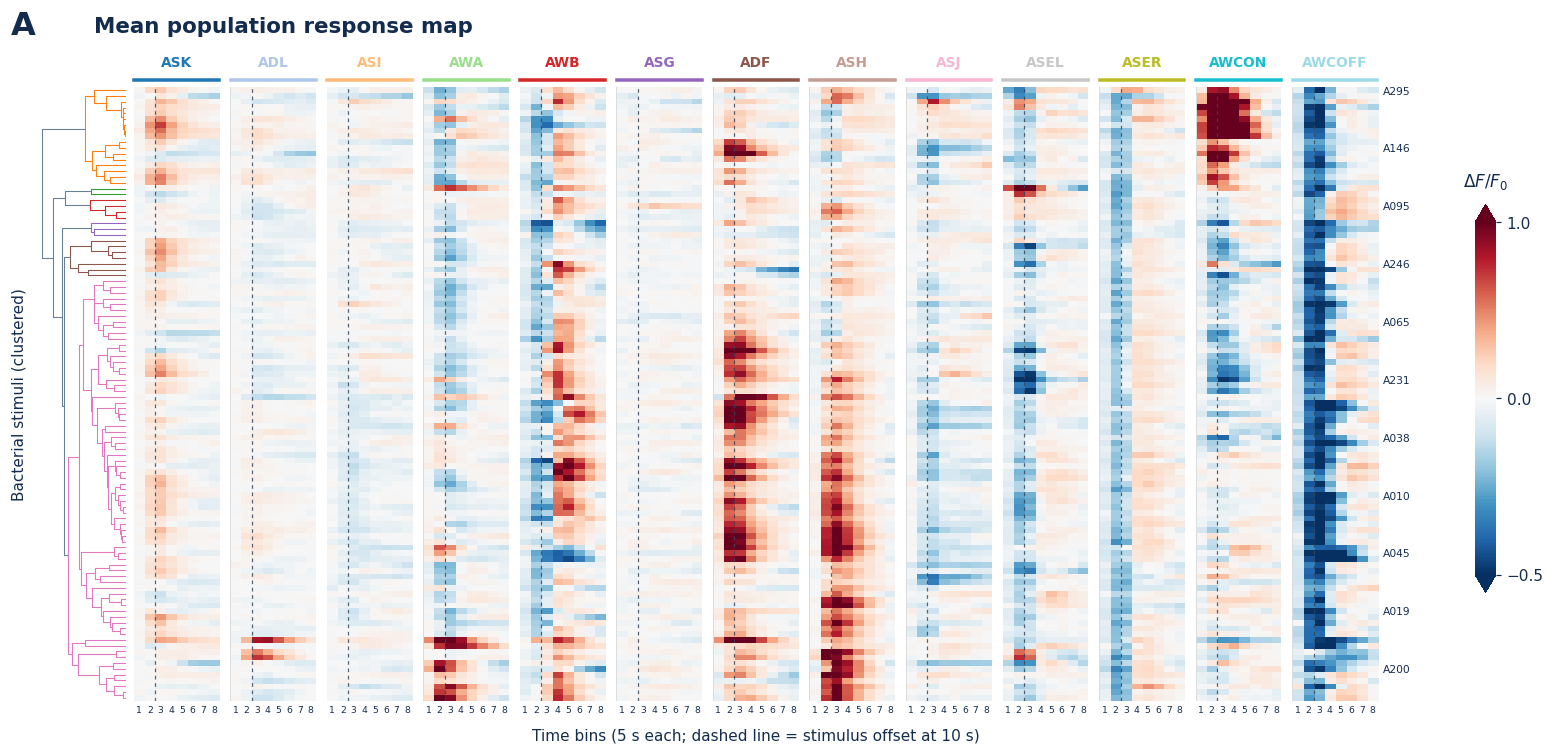

In [3]:
# A — mean response atlas. Rows use average linkage of mean-profile cosine.
# Every bacterium is retained; labels are thinned only for visual readability.
a_cube = final_profiles.to_numpy(dtype=float).reshape(
    len(final_profiles), len(FINAL_CLASSES), len(FINAL_BINS),
)
a_similarity, _ = final_shared_cosine(a_cube, a_cube)
a_tree = final_linkage(a_similarity)
A_PANEL_Y_SHIFT = 0.06  # Fraction of figure height; move heatmap, tree, and colorbar together.
with plt.rc_context(FINAL_STYLE):
    fig_a = plt.figure(figsize=(14.5, 8.2))
    final_title(fig_a, "A", "Mean population response map")
    # fig_a.text(
    #     0.07, 0.922, f"{len(final_profiles)} bacterial stimuli · "
    #     f"{len(FINAL_CLASSES)} neuron classes · {len(FINAL_BINS)} time bins",
    #     fontsize=10, color="#687F99",
    # )
    ax_a_tree = fig_a.add_axes([0.035, 0.16 + A_PANEL_Y_SHIFT, 0.055, 0.68])
    ax_a = fig_a.add_axes([0.095, 0.16 + A_PANEL_Y_SHIFT, 0.78, 0.68])
    a_dendrogram = dendrogram(
        a_tree, ax=ax_a_tree, orientation="left", no_labels=True,
        color_threshold=0.7 * a_tree[:, 2].max(), above_threshold_color="#687F99",
    )
    ax_a_tree.set_ylim(10 * len(final_profiles), 0)
    ax_a_tree.axis("off")
    for collection in ax_a_tree.collections:
        collection.set_linewidth(0.7)
    a_order = a_dendrogram["leaves"]
    a_ids = final_profiles.index.take(a_order)
    a_nbins = len(FINAL_BINS)
    # The exclusive stimulus offset falls after the second 5-volume bin.
    a_offset_bin = (FINAL_OFFSET - FINAL_ONSET) / FINAL_BIN_POINTS - 0.5
    # A white gap separates neuron classes; NaN within a class stays gray.
    a_display = np.full((len(a_ids), len(FINAL_CLASSES) * (a_nbins + 1) - 1), np.nan)
    for k in range(len(FINAL_CLASSES)):
        a_display[:, k * (a_nbins + 1):k * (a_nbins + 1) + a_nbins] = a_cube[a_order, k, :]
    a_cmap = plt.get_cmap("RdBu_r").copy()
    a_cmap.set_bad("#DCDCDC")
    a_image = ax_a.imshow(
        a_display, cmap=a_cmap,
        norm=TwoSlopeNorm(vmin=A_COLOR_LIMITS[0], vcenter=0, vmax=A_COLOR_LIMITS[1]),
        origin="upper", aspect="auto", interpolation="nearest", rasterized=True,
    )
    a_colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(FINAL_CLASSES)))
    for k, (neuron_class, color) in enumerate(zip(FINAL_CLASSES, a_colors)):
        start = k * (a_nbins + 1)
        if k:
            ax_a.axvspan(start - 1.5, start - 0.5, color="white", linewidth=0)
        ax_a.axvline(start + a_offset_bin, color="#36465A",
                     linestyle=(0, (3, 3)), linewidth=0.8, alpha=0.85, zorder=4)
        ax_a.plot([start - 0.45, start + a_nbins - 0.55], [1.012, 1.012],
                  color=color, linewidth=2.3, transform=ax_a.get_xaxis_transform(), clip_on=False)
        ax_a.text(start + (a_nbins - 1) / 2, 1.034, neuron_class,
                  color=color, ha="center", fontsize=9, weight="bold",
                  transform=ax_a.get_xaxis_transform())
    a_ticks = [k * (a_nbins + 1) + j for k in range(len(FINAL_CLASSES)) for j in range(a_nbins)]
    ax_a.set_xticks(a_ticks, list(range(1, a_nbins + 1)) * len(FINAL_CLASSES), fontsize=6)
    a_rows = np.arange(0, len(a_ids), A_LABEL_STEP)
    ax_a.set_yticks(a_rows, a_ids[a_rows], fontsize=7)
    ax_a.yaxis.tick_right()
    ax_a.tick_params(length=0, pad=3)
    ax_a.set_xlabel(
        f"Time bins ({FINAL_BIN_POINTS * FINAL_VOLUME_INTERVAL_S:g} s each; "
        f"dashed line = stimulus offset at "
        f"{(FINAL_OFFSET - FINAL_ONSET) * FINAL_VOLUME_INTERVAL_S:g} s)",
        labelpad=9,
    )
    ax_a_tree.text(-0.13, 0.5, "Bacterial stimuli (clustered)", rotation=90,
                   ha="right", va="center", transform=ax_a_tree.transAxes)
    for spine in ax_a.spines.values():
        spine.set_visible(False)
    a_cax = fig_a.add_axes([0.936, 0.28 + A_PANEL_Y_SHIFT, 0.013, 0.43])
    a_cax.set_title(r"$\Delta F/F_0$", fontsize=11, pad=12)
    a_colorbar = fig_a.colorbar(
        a_image, cax=a_cax, ticks=[A_COLOR_LIMITS[0], 0, A_COLOR_LIMITS[1]],
        extend=final_colorbar_extend(a_cube, A_COLOR_LIMITS),
    )
    a_colorbar.outline.set_visible(False)
    # fig_a.text(0.095, 0.045, "Gray: unobserved response", color="#687F99", fontsize=8)
    final_save_table(final_profiles.loc[a_ids], "panel_a_mean_profiles")
    final_save_table(pd.DataFrame({"position": np.arange(1, len(a_ids) + 1), "sample_id": a_ids}),
                     "panel_a_row_order", index=False)
    final_show(fig_a, "panel_a_response_atlas")


Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_b_cross_half_similarity.png
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_b_cross_half_similarity.pdf


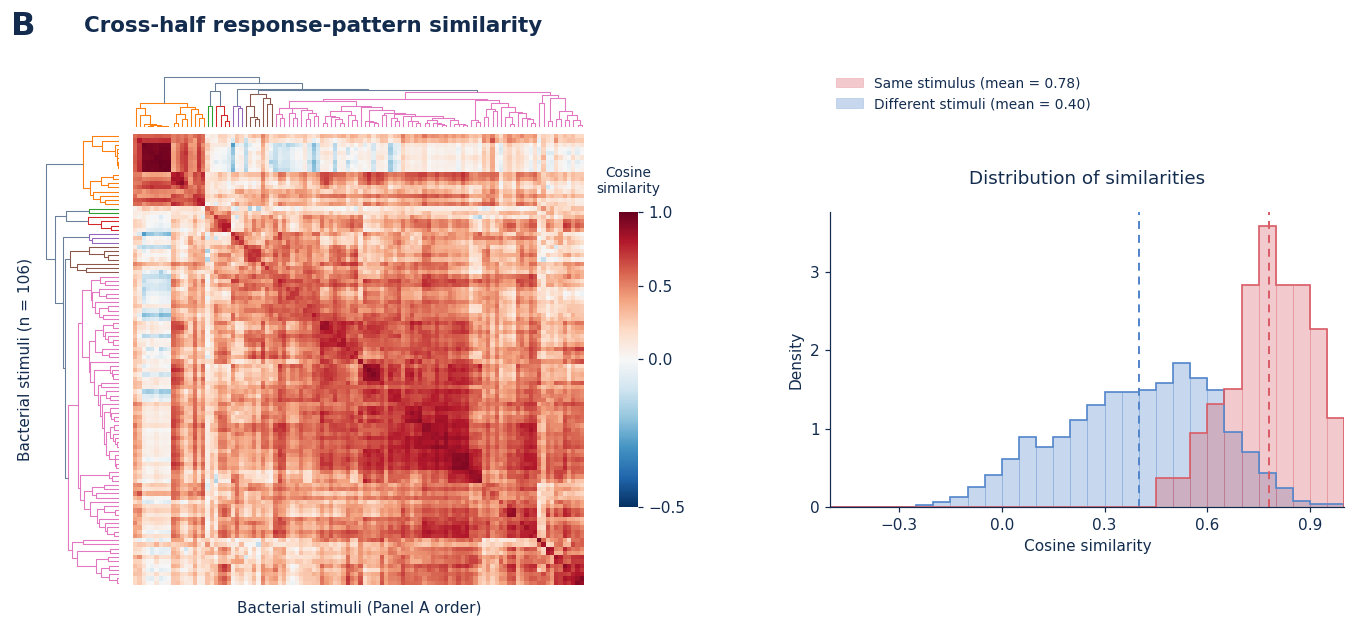

In [4]:
# B — animal split halves. Each split keeps all bins/classes of an animal together.
# Dates are pooled within stimulus, exactly as in the previous Panel B method.
def final_split_similarity(vectors, repeats, seed):
    samples = vectors.index.get_level_values("sample_id").unique().tolist()
    arrays = [vectors.xs(sample, level="sample_id").to_numpy(dtype=float) for sample in samples]
    if repeats < 1 or any(len(values) < 2 for values in arrays):
        raise ValueError("Require positive repeats and at least two animals per stimulus")
    rng = np.random.default_rng(seed)
    n, nc, nb = len(samples), len(FINAL_CLASSES), len(FINAL_BINS)
    total, shared_total = np.zeros((n, n)), np.zeros((n, n))
    count = np.zeros((n, n), dtype=int)
    for _ in range(repeats):
        a, b = np.empty((n, nc, nb)), np.empty((n, nc, nb))
        for row, values in enumerate(arrays):
            permutation = rng.permutation(len(values))
            cut = len(values) // 2
            a[row] = final_mean_animals(values[permutation[:cut]]).reshape(nc, nb)
            b[row] = final_mean_animals(values[permutation[cut:]]).reshape(nc, nb)
        ab, shared = final_shared_cosine(a, b)
        valid_ab = np.isfinite(ab)
        directions = valid_ab.astype(int) + valid_ab.T.astype(int)
        symmetric = np.divide(
            np.where(valid_ab, ab, 0) + np.where(valid_ab.T, ab.T, 0), directions,
            out=np.full_like(ab, np.nan), where=directions > 0,
        )
        valid = directions > 0
        total[valid] += symmetric[valid]
        count[valid] += 1
        shared_total[valid] += shared[valid]
    if not np.all(count > 0):
        raise ValueError("Some pairs have no defined shared-class cosine; inspect coverage")
    return tuple(pd.DataFrame(x, index=samples, columns=samples)
                 for x in (total / count, count, shared_total / count))


final_b_similarity, final_b_valid_splits, final_b_shared_classes = final_split_similarity(
    final_vectors, B_REPEATS, B_SEED,
)
b_values = final_b_similarity.to_numpy(dtype=float)
b_same = np.diag(b_values)
b_other = b_values[np.triu_indices(len(b_values), k=1)]
# Recompute Panel A's profile tree so B has the same order without running Cell 42.
a_reference_cube = final_profiles.to_numpy(dtype=float).reshape(
    len(final_profiles), len(FINAL_CLASSES), len(FINAL_BINS),
)
a_reference_similarity, _ = final_shared_cosine(a_reference_cube, a_reference_cube)
a_reference_tree = final_linkage(a_reference_similarity)
with plt.rc_context(FINAL_STYLE):
    fig_b = plt.figure(figsize=(12.8, 6.4))
    final_title(fig_b, "B", "Cross-half response-pattern similarity")
    # fig_b.text(0.105, 0.925, f"Mean of {B_REPEATS} animal splits", color="#687F99", fontsize=9)
    ax_b = fig_b.add_axes([0.105, 0.17, 0.32, 0.64])
    ax_b_top = fig_b.add_axes([0.105, 0.82, 0.32, 0.075])
    ax_b_left = fig_b.add_axes([0.04, 0.17, 0.055, 0.64])
    # Both dendrograms show Panel A's hierarchy; B colors remain split-half cosine.
    b_tree_style = dict(no_labels=True, color_threshold=0.7 * a_reference_tree[:, 2].max(),
                        above_threshold_color="#687F99")
    a_leaves = dendrogram(a_reference_tree, ax=ax_b_top, **b_tree_style)["leaves"]
    dendrogram(a_reference_tree, ax=ax_b_left, orientation="left", **b_tree_style)
    a_ordered_ids = final_profiles.index.take(a_leaves)
    b_order = final_b_similarity.index.get_indexer(a_ordered_ids)
    if len(b_order) != len(b_values) or (b_order < 0).any():
        raise ValueError("Panels A and B must contain the same bacterial stimuli")
    ax_b_top.set_xlim(0, 10 * len(b_values))
    ax_b_left.set_ylim(10 * len(b_values), 0)
    for axis in (ax_b_top, ax_b_left):
        axis.axis("off")
        for collection in axis.collections:
            collection.set_linewidth(0.7)
    b_image = ax_b.imshow(
        b_values[np.ix_(b_order, b_order)], cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=B_COLOR_LIMITS[0], vcenter=0, vmax=B_COLOR_LIMITS[1]),
        origin="upper", aspect="equal", interpolation="nearest", rasterized=True,
    )
    ax_b.set_xticks([])
    ax_b.set_yticks([])
    ax_b.set_xlabel("Bacterial stimuli (Panel A order)", labelpad=10)
    ax_b_left.text(-0.12, 0.5, f"Bacterial stimuli (n = {len(b_values)})", rotation=90,
                   ha="right", va="center", transform=ax_b_left.transAxes)
    for spine in ax_b.spines.values():
        spine.set_visible(False)
    b_cax = fig_b.add_axes([0.45, 0.28, 0.013, 0.42])
    b_cax.set_title("Cosine\nsimilarity", fontsize=9, pad=12)
    b_colorbar = fig_b.colorbar(b_image, cax=b_cax, ticks=[-0.5, 0, 0.5, 1],
                               extend=final_colorbar_extend(b_values, B_COLOR_LIMITS))
    b_colorbar.outline.set_visible(False)
    ax_b_hist = fig_b.add_axes([0.60, 0.28, 0.365, 0.42])
    ax_b_hist.set_title("Distribution of similarities", fontsize=12, pad=18)
    b_low = min(-0.5, np.floor(b_values.min() / B_HIST_BIN_WIDTH) * B_HIST_BIN_WIDTH)
    b_high = max(1.0, np.ceil(b_values.max() / B_HIST_BIN_WIDTH) * B_HIST_BIN_WIDTH)
    b_bins = np.linspace(b_low, b_high, round((b_high - b_low) / B_HIST_BIN_WIDTH) + 1)
    for values, color, label in [(b_other, "#5386CB", "Different stimuli"),
                                  (b_same, "#D95D67", "Same stimulus")]:
        ax_b_hist.hist(values, bins=b_bins, density=True, color=color, alpha=0.32,
                       edgecolor=color, linewidth=0.5,
                       label=f"{label} (mean = {values.mean():.2f})")
        ax_b_hist.hist(values, bins=b_bins, density=True, histtype="step", color=color, linewidth=1.1)
        ax_b_hist.axvline(values.mean(), color=color, linestyle=(0, (4, 3)), linewidth=1.3)
    ax_b_hist.set(xlim=(b_low, b_high), xlabel="Cosine similarity", ylabel="Density")
    ax_b_hist.xaxis.set_major_locator(MaxNLocator(5))
    ax_b_hist.yaxis.set_major_locator(MaxNLocator(4))
    ax_b_hist.spines[["top", "right"]].set_visible(False)
    handles, labels = ax_b_hist.get_legend_handles_labels()
    fig_b.legend(handles[::-1], labels[::-1], loc="upper left", bbox_to_anchor=(0.595, 0.91),
                  frameon=False, fontsize=9)
    # fig_b.text(0.60, 0.14, f"{len(b_same)} diagonal entries; {len(b_other):,} unique off-diagonal pairs",
    #             fontsize=8, color="#687F99")
    final_save_table(final_b_similarity, "panel_b_similarity")
    final_save_table(final_b_valid_splits, "panel_b_valid_splits")
    final_save_table(final_b_shared_classes, "panel_b_mean_shared_classes")
    final_save_table(pd.DataFrame({"position": np.arange(1, len(b_order) + 1),
                                   "sample_id": a_ordered_ids}),
                     "panel_b_row_order", index=False)
    final_save_table(pd.DataFrame({"sample_id": final_b_similarity.index,
                                   "same_similarity": b_same,
                                   "mean_other_similarity": (b_values.sum(axis=1) - b_same) / (len(b_values) - 1)}),
                     "panel_b_self_vs_other", index=False)
    final_show(fig_b, "panel_b_cross_half_similarity")


Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_c_cross_date_similarity.png
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_c_cross_date_similarity.pdf


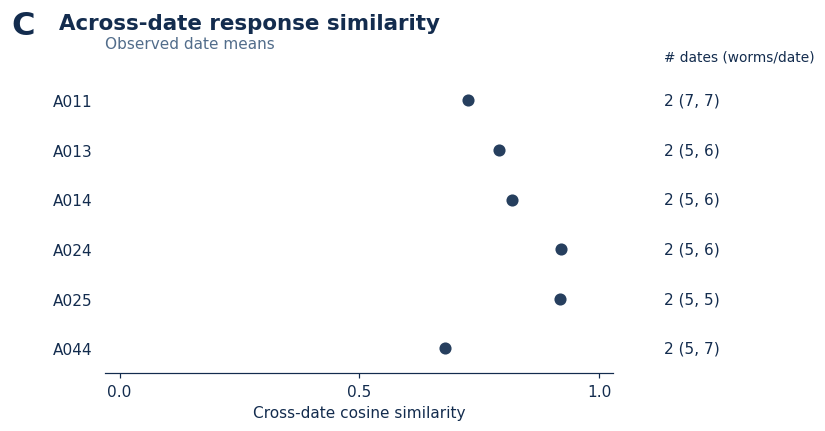

sample_id  bootstrap_requested  bootstrap_valid  bootstrap_missing_features  bootstrap_zero_norm
     A011                 2000             1903                          97                    0
     A013                 2000             1951                          49                    0
     A014                 2000             1960                          40                    0
     A024                 2000             1968                          32                    0
     A025                 2000             1928                          72                    0
     A044                 2000             1953                          47                    0
C shows observed date-mean cosine only; bootstrap draws are saved but not plotted.


In [5]:
# C — animal-bootstrap distributions of cross-date mean-response cosine.
# Resample whole animals independently within each date; never pool the dates.
# Four 5-volume bins: original indices 5–24, sampled times 0–19 s, window [0, 20) s.
C_BINS = FINAL_BINS[:4]
C_N_BOOTSTRAPS = 2000
C_SEED = 20260920
C_COLUMNS = pd.MultiIndex.from_product(
    [FINAL_CLASSES, C_BINS], names=["neuron_class", "time_bin"],
)


def c_bootstrap_date_pair(first, second, repeats, seed):
    """Arrays: animal × fixed neuron-bin features; preserve each animal's vector.

    Columns have already been restricted to the original date pair's complete
    shared classes. A draw missing any fixed feature is invalid, not zero-filled
    or scored on a smaller neuron set. The plotted density uses valid draws.
    """
    rng = np.random.default_rng(seed)
    scores = np.full(repeats, np.nan)
    status = np.full(repeats, "missing_fixed_features", dtype="U24")
    if first.shape[1] == 0:
        status[:] = "no_shared_classes"
        return scores, status
    for repeat in range(repeats):
        a = final_mean_animals(first[rng.integers(0, len(first), len(first))])
        b = final_mean_animals(second[rng.integers(0, len(second), len(second))])
        if not (np.isfinite(a).all() and np.isfinite(b).all()):
            continue
        denominator = np.linalg.norm(a) * np.linalg.norm(b)
        if denominator <= 1e-12:
            status[repeat] = "zero_response_norm"
            continue
        scores[repeat] = np.clip(a @ b / denominator, -1, 1)
        status[repeat] = "valid"
    return scores, status


if C_N_BOOTSTRAPS < 2 or not C_BINS:
    raise ValueError("Require at least two bootstrap draws and one time bin")
c_vectors = final_vectors.reindex(columns=C_COLUMNS)
c_date_counts = c_vectors.notna().any(axis=1).groupby(level=["sample_id", "date"]).sum().astype(int)
c_records, c_count_records, c_bootstrap_frames = [], [], []
for sample in final_repeated:
    date_means = final_date_means.xs(sample, level="sample_id").reindex(columns=C_COLUMNS).sort_index()
    dates = list(date_means.index)
    for number, date in enumerate(dates, start=1):
        c_count_records.append({"sample_id": sample, "session": f"Session {number}", "date": date,
                                "n_animals": int(c_date_counts.loc[(sample, date)])})
    for date_a, date_b in combinations(dates, 2):
        first = date_means.loc[date_a].to_numpy(dtype=float).reshape(1, len(FINAL_CLASSES), len(C_BINS))
        second = date_means.loc[date_b].to_numpy(dtype=float).reshape(first.shape)
        observed, shared_count = final_shared_cosine(first, second)
        shared = np.isfinite(first[0]).all(axis=1) & np.isfinite(second[0]).all(axis=1)
        feature_mask = np.repeat(shared, len(C_BINS))
        animals_a = c_vectors.xs((sample, date_a), level=["sample_id", "date"]).to_numpy(dtype=float)
        animals_b = c_vectors.xs((sample, date_b), level=["sample_id", "date"]).to_numpy(dtype=float)
        # Stable per-pair seed: other rows can be added/reordered without changing this pair.
        pair_key = f"{sample}|{date_a}|{date_b}".encode("utf-8")
        pair_seed = int.from_bytes(hashlib.sha256(pair_key).digest()[:8], "little") ^ C_SEED
        scores, status = c_bootstrap_date_pair(
            animals_a[:, feature_mask], animals_b[:, feature_mask], C_N_BOOTSTRAPS, pair_seed,
        )
        valid = scores[np.isfinite(scores)]
        quantiles = np.quantile(valid, [0.025, 0.5, 0.975]) if len(valid) else [np.nan] * 3
        c_records.append({
            "sample_id": sample, "date_a": date_a, "date_b": date_b,
            "session_a": f"Session {dates.index(date_a) + 1}",
            "session_b": f"Session {dates.index(date_b) + 1}",
            "n_dates": len(dates), "cosine_similarity": float(observed[0, 0]),
            "n_bins": len(C_BINS), "bins_used": ";".join(C_BINS),
            "n_animals_a": int(c_date_counts.loc[(sample, date_a)]),
            "n_animals_b": int(c_date_counts.loc[(sample, date_b)]),
            "n_shared_classes": int(shared_count[0, 0]),
            "shared_neuron_classes": ";".join(np.asarray(FINAL_CLASSES)[shared]),
            "bootstrap_requested": C_N_BOOTSTRAPS, "bootstrap_valid": len(valid),
            "bootstrap_missing_features": int(np.sum(status == "missing_fixed_features")),
            "bootstrap_zero_norm": int(np.sum(status == "zero_response_norm")),
            "bootstrap_q025": quantiles[0], "bootstrap_median": quantiles[1], "bootstrap_q975": quantiles[2],
            "pair_seed": pair_seed,
        })
        c_bootstrap_frames.append(pd.DataFrame({
            "sample_id": sample, "date_a": date_a, "date_b": date_b,
            "repeat": np.arange(1, C_N_BOOTSTRAPS + 1),
            "cosine_similarity": scores, "status": status,
        }))
if not c_records:
    raise ValueError("No stimuli were measured on multiple dates")
final_c_pairs = pd.DataFrame(c_records)
final_c_counts = pd.DataFrame(c_count_records)
final_c_bootstrap = pd.concat(c_bootstrap_frames, ignore_index=True)

with plt.rc_context(FINAL_STYLE):
    fig_c, ax_c = plt.subplots(figsize=(8.4, max(3.7, 1.4 + 0.45 * len(final_repeated))))
    fig_c.subplots_adjust(left=0.12, right=0.67, bottom=0.18, top=0.84)
    final_title(fig_c, "C", "Across-date response similarity")
    fig_c.text(0.12, 0.90, "Observed date means", fontsize=10, color="#526D8B")
    for row, sample in enumerate(final_repeated):
        pairs = final_c_pairs.loc[final_c_pairs["sample_id"].eq(sample)]
        offsets = np.linspace(-0.23, 0.23, len(pairs)) if len(pairs) > 1 else np.array([0.0])
        for (_, pair), offset in zip(pairs.iterrows(), offsets):
            y = row + offset
            if np.isfinite(pair["cosine_similarity"]):
                ax_c.scatter(pair["cosine_similarity"], y, s=48, color="#263F5E", zorder=3)
            else:
                ax_c.text(0.02, y, "Similarity undefined", transform=ax_c.get_yaxis_transform(),
                          va="center", fontsize=8)
        counts = final_c_counts.loc[final_c_counts["sample_id"].eq(sample), "n_animals"]
        ax_c.text(1.10, row, f"{len(counts)} ({', '.join(map(str, counts))})",
                  transform=ax_c.get_yaxis_transform(), va="center", fontsize=10)
    ax_c.text(1.10, 1.04, "# dates (worms/date)", transform=ax_c.transAxes, fontsize=9, va="bottom")
    c_lower = -1 if final_c_pairs["cosine_similarity"].lt(0).any() else 0
    ax_c.set(xlim=(c_lower - 0.03, 1.03), ylim=(len(final_repeated) - 0.5, -0.5),
             xlabel="Cross-date cosine similarity")
    ax_c.set_xticks([-1, -0.5, 0, 0.5, 1] if c_lower < 0 else [0, 0.5, 1])
    ax_c.set_yticks(np.arange(len(final_repeated)), final_repeated)
    ax_c.spines[["top", "right", "left"]].set_visible(False)
    ax_c.tick_params(axis="y", length=0, pad=8)
    final_save_table(final_c_pairs, "panel_c_date_pairs", index=False)
    final_save_table(final_c_counts, "panel_c_session_key", index=False)
    final_save_table(final_c_bootstrap, "panel_c_animal_bootstrap", index=False)
    if FINAL_SAVE:
        with FINAL_RAW.open("rb") as c_raw_file:
            c_raw_hash = hashlib.file_digest(c_raw_file, "sha256").hexdigest()
        c_parameters = {
            "raw_file": str(FINAL_RAW), "raw_sha256": c_raw_hash,
            "bins_used": C_BINS, "neuron_classes": FINAL_CLASSES,
            "n_bootstraps_per_pair": C_N_BOOTSTRAPS, "seed": C_SEED,
            "sampling_unit": "whole animal; independent sampling with replacement within each date",
            "sample_size": "original animal count of each date",
            "features": "fixed complete shared neuron classes from original date means",
            "invalid_draws": "missing any fixed feature or zero response norm; retained in CSV",
            "figure": "observed date-mean cosine only; bootstrap draws saved in CSV",
            "interpretation": "sampling variability conditional on observed dates and complete feature coverage; not new date replicates",
        }
        (FINAL_OUTPUT / "panel_c_bootstrap_parameters.json").write_text(
            json.dumps(c_parameters, ensure_ascii=False, indent=2), encoding="utf-8",
        )
    final_show(fig_c, "panel_c_cross_date_similarity")
print(final_c_pairs[["sample_id", "bootstrap_requested", "bootstrap_valid",
                     "bootstrap_missing_features", "bootstrap_zero_norm"]].to_string(index=False))
print("C shows observed date-mean cosine only; bootstrap draws are saved but not plotted.")


Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_d_repeat_traces.png
Saved: h:\Process_temporary\WJH\bacteria_analysis\output\02_reproducibility_figures\panel_d_repeat_traces.pdf


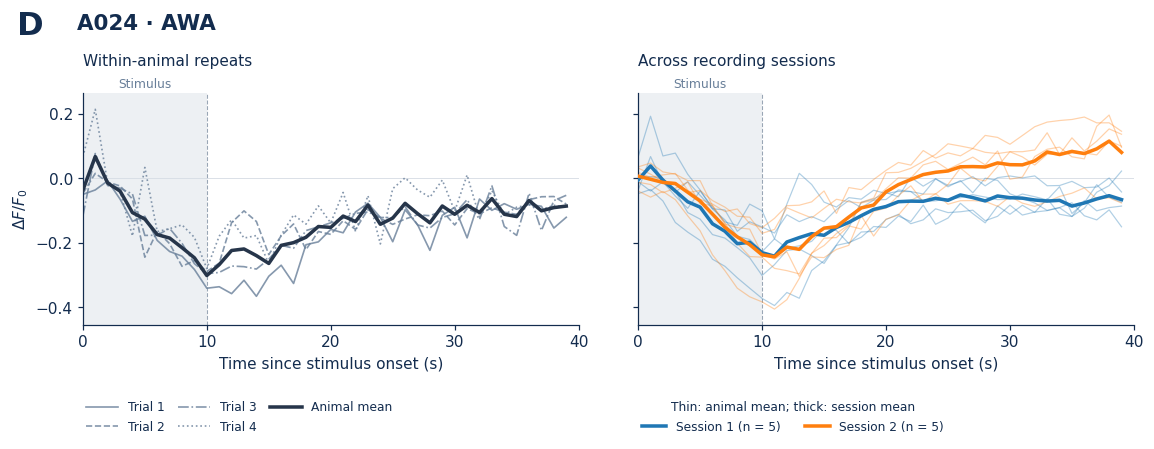

In [6]:
# D — one stimulus × neuron class, shown at two repeat levels.
# Defaults preserve the current example. Set selection parameters to None in
# the setup cell for the first eligible combination in ID order (not response rank).
def final_select_traces(traces, sample_id, neuron_class, date, worm_key):
    selected = traces.loc[traces["neuron_class"].isin(FINAL_CLASSES)].copy()
    for column, requested in [("sample_id", sample_id), ("neuron_class", neuron_class)]:
        if requested is not None:
            selected = selected.loc[selected[column].eq(requested)].copy()
    for column in ["sample_id", "neuron_class", "date", "worm_key"]:
        selected[column] = selected[column].astype(str)
    keys = ["sample_id", "neuron_class", "date", "worm_key", "segment_index"]
    trials = selected.pivot(index=keys, columns="time_point", values="delta_F_over_F0").reindex(columns=FINAL_POINTS)
    observed = trials.loc[trials.notna().any(axis=1)]
    candidates = observed.groupby(level=keys[:-1]).size().rename("n_trials").reset_index()
    dates_per_response = candidates.groupby(["sample_id", "neuron_class"])["date"].transform("nunique")
    candidates = candidates.loc[candidates["n_trials"].ge(2) & dates_per_response.ge(2)]
    for column, requested in [("date", date), ("worm_key", worm_key)]:
        if requested is not None:
            candidates = candidates.loc[candidates[column].eq(requested)]
    if candidates.empty:
        raise ValueError("No matching example has multiple dates and an animal with >=2 trials; check D parameters")
    choice = candidates.sort_values(keys[:-1]).iloc[0]
    response = trials.xs((choice["sample_id"], choice["neuron_class"]),
                         level=["sample_id", "neuron_class"]).sort_index()
    within = response.xs((choice["date"], choice["worm_key"]), level=["date", "worm_key"]).sort_index()
    animals = response.groupby(level=["date", "worm_key"]).mean()
    means = animals.groupby(level="date").mean()
    return choice, response, within, animals, means


d_choice, d_trials, d_within, d_animals, d_means = final_select_traces(
    final_trials, D_SAMPLE_ID, D_NEURON_CLASS, D_DATE, D_WORM_KEY,
)
d_dates = list(d_means.index)
d_labels = {date: f"Session {i + 1}" for i, date in enumerate(d_dates)}
d_counts = d_animals.notna().any(axis=1).groupby(level="date").sum().astype(int)
d_time = (FINAL_POINTS - FINAL_ONSET) * FINAL_VOLUME_INTERVAL_S
d_duration = (FINAL_OFFSET - FINAL_ONSET) * FINAL_VOLUME_INTERVAL_S
d_trial_order = pd.DataFrame({
    "sample_id": d_choice["sample_id"], "neuron_class": d_choice["neuron_class"],
    "session": d_labels[d_choice["date"]], "date": d_choice["date"], "worm_key": d_choice["worm_key"],
    "trial_order": np.arange(1, len(d_within) + 1), "segment_index": d_within.index,
})
d_key = pd.DataFrame({"session": [d_labels[date] for date in d_dates], "date": d_dates,
                       "n_animals": [int(d_counts.loc[date]) for date in d_dates]})
with plt.rc_context(FINAL_STYLE):
    fig_d, (ax_d_left, ax_d_right) = plt.subplots(1, 2, figsize=(10.5, 4.3), sharex=True, sharey=True)
    fig_d.subplots_adjust(left=0.075, right=0.985, bottom=0.32, top=0.81, wspace=0.12)
    final_title(fig_d, "D", f"{d_choice['sample_id']} · {d_choice['neuron_class']}")
    dashes = ["-", "--", "-.", ":", (0, (5, 1, 1, 1)), (0, (3, 1, 1, 1, 1, 1))]
    for order, (segment, trace) in enumerate(d_within.iterrows(), start=1):
        dash = dashes[order - 1] if order <= len(dashes) else (0, (order, 1))
        ax_d_left.plot(d_time, trace, color="#687F99", linewidth=1.1,
                        linestyle=dash, alpha=0.8, label=f"Trial {order}")
    ax_d_left.plot(d_time, d_within.mean(axis=0), color="#26354A", linewidth=2.3,
                    label="Animal mean", zorder=4)
    ax_d_left.set_title("Within-animal repeats", loc="left", fontsize=10, pad=18)
    d_colors = plt.get_cmap("tab10")
    for i, date in enumerate(d_dates):
        color = d_colors(i % 10)
        for _, trace in d_animals.xs(date, level="date").iterrows():
            ax_d_right.plot(d_time, trace, color=color, linewidth=0.8, alpha=0.35)
        ax_d_right.plot(d_time, d_means.loc[date], color=color, linewidth=2.3,
                         label=f"{d_labels[date]} (n = {d_counts.loc[date]})", zorder=4)
    ax_d_right.set_title("Across recording sessions", loc="left", fontsize=10, pad=18)
    d_finite = np.concatenate([d_within.to_numpy().ravel(), d_animals.to_numpy().ravel()])
    d_finite = d_finite[np.isfinite(d_finite)]
    d_lower, d_upper = min(0, d_finite.min()), max(0, d_finite.max())
    d_pad = 0.08 * max(d_upper - d_lower, 0.1)
    for axis in (ax_d_left, ax_d_right):
        axis.axvspan(0, d_duration, color="#D8DEE5", alpha=0.45, linewidth=0, zorder=0)
        axis.axvline(d_duration, color="#99A6B5", linestyle="--", linewidth=0.7, zorder=1)
        axis.axhline(0, color="#D8DEE5", linewidth=0.6, zorder=0)
        axis.text(d_duration / 2, 1.025, "Stimulus", transform=axis.get_xaxis_transform(),
                    ha="center", fontsize=8, color="#687F99")
        axis.set(xlim=(0, FINAL_WINDOW_POINTS * FINAL_VOLUME_INTERVAL_S),
                   ylim=(d_lower - d_pad, d_upper + d_pad) if D_YLIM is None else D_YLIM,
                   xlabel="Time since stimulus onset (s)")
        axis.set_xticks([0, 10, 20, 30, 40])
        axis.spines[["top", "right"]].set_visible(False)
        axis.tick_params(length=3, width=0.8)
    ax_d_left.set_ylabel(r"$\Delta F/F_0$")
    ax_d_left.legend(loc="upper left", bbox_to_anchor=(-0.015, -0.28), ncol=3,
                      frameon=False, fontsize=8, handlelength=2.6, columnspacing=1.1)
    ax_d_right.legend(title="Thin: animal mean; thick: session mean", title_fontsize=8,
                       loc="upper left", bbox_to_anchor=(-0.015, -0.28), ncol=2, frameon=False, fontsize=8)
    final_save_table(d_trial_order, "panel_d_selected_trials", index=False)
    final_save_table(d_key, "panel_d_session_key", index=False)
    final_save_table(d_within, "panel_d_within_animal_traces")
    final_save_table(d_animals, "panel_d_animal_mean_traces")
    final_save_table(d_means, "panel_d_session_mean_traces")
    final_save_table(d_trials.groupby(level=["date", "worm_key"]).count(), "panel_d_trial_counts_by_volume")
    final_save_table(d_animals.groupby(level="date").count(), "panel_d_animal_counts_by_volume")
    final_show(fig_d, "panel_d_repeat_traces")


Observation:
展示性的内容可以使用A与B，但变异性值得更进一步探索，需要对数据有足够的了解
D值得展开探讨一下 individual内变异性、individual间变异性在每个neuron有多大
C D可以作为探索性figure，不作为poster展示